<a href="https://colab.research.google.com/github/tivanello/fase5/blob/main/notebooks/fase5_pergunta9_modelo_preditivo_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOCO 1 —IMPORTAR O DATAFRAME do Git
# Objetivo:
# - Clonar o repositório no Colab
# - Localizar o arquivo tratado
# - Carregar o arquivo df_fase5.csv em um DataFrame
# ============================================================

import os
import pandas as pd

REPO_DIR = "/content/fase5"
ARQUIVO = f"{REPO_DIR}/data/processed/df_fase5.csv"

# Clonar o repositório apenas se ainda não existir
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/tivanello/fase5.git {REPO_DIR}
else:
    print("Repositório já existe no ambiente.")

# Carregar o arquivo
df_fase5 = pd.read_csv(ARQUIVO)

# Conferência inicial
print("Dimensão do dataframe:", df_fase5.shape)
display(df_fase5.head())

Cloning into '/content/fase5'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 211 (delta 17), reused 0 (delta 0), pack-reused 183 (from 1)
Receiving objects: 100% (211/211), 62.89 MiB | 13.49 MiB/s, done.
Resolving deltas: 100% (79/79), done.
Dimensão do dataframe: (3030, 72)


,RA,Fase,Turma,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,...,Avaliador6_id,FaseIdeal_txt,Fase_num,Fase_sufixo,FaseIdeal_num,ra_num,INDE_final,INDE_fonte,PEDRA_final,PEDRA_fonte
0,RA-1,7,A,2003.0,19.0,Menina,2016,Escola Pública,Ametista,Ametista,...,NaN,Fase 8 (Universitários),7.0,NaN,8,1,5.783,INDE 2022,Quartzo,Pedra 2022
1,RA-2,7,A,2005.0,17.0,Menina,2017,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.0,NaN,7,2,7.055,INDE 2022,Ametista,Pedra 2022
2,RA-3,7,A,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.0,NaN,7,3,6.591,INDE 2022,Ágata,Pedra 2022
3,RA-4,7,A,2005.0,17.0,Menino,2017,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.0,NaN,7,4,5.951,INDE 2022,Quartzo,Pedra 2022
4,RA-5,7,A,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,Ametista,...,NaN,Fase 7 (3º EM),7.0,NaN,7,5,7.427,INDE 2022,Ametista,Pedra 2022


In [2]:
df_fase5.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 72 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Ano nasc               860 non-null    float64
 4   Idade 22               860 non-null    float64
 5   Gênero                 3030 non-null   object 
 6   Ano ingresso           3030 non-null   int64  
 7   Instituição de ensino  3029 non-null   object 
 8   Pedra 20               754 non-null    object 
 9   Pedra 21               1061 non-null   object 
 10  Pedra 22               1932 non-null   object 
 11  INDE 22                1932 non-null   float64
 12  Cg                     860 non-null    float64
 13  Cf                     860 non-null    float64
 14  Ct                     860 non-null    float64
 15  Nº A

In [3]:
# ============================================================
# BLOCO 1.1 DIAGNÓSTICO da base
# Objetivo:
# - Verificar possíveis sujeiras no df_fase5 que possam impactar o treinamento do modelo
# - Comparar nomes de colunas e valores categóricos críticos
# ============================================================

def diagnostico_texto(df, nome_df):
    print(f"\n{'='*80}")
    print(f"DIAGNÓSTICO: {nome_df}")
    print(f"{'='*80}")

    print("\nColunas:")
    print(df.columns.tolist())

    colunas_teste = [
        "Fase",
        "Turma",
        "Gênero",
        "Instituição de ensino",
        "Pedra 22",
        "Ano ingresso",
        "Ano nasc",
        "Data de Nasc",
        "Idade 22",
        "Fase_num",
        "FaseIdeal_num",
        "FaseIdeal_txt",
        "INDE_final",
        "PEDRA_final",
        "Defasagem_final",
        "alvo_risco_defasagem"
    ]

    for col in colunas_teste:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print("dtype:", df[col].dtype)
            print("Nulos:", df[col].isna().sum())
            print("Amostra valores únicos:")
            print(sorted(df[col].dropna().astype(str).unique())[:50])
        else:
            print(f"\n--- {col} ---")
            print("Coluna não encontrada")

# 1) Diagnóstico da base principal
diagnostico_texto(df_fase5, "df_fase5")



DIAGNÓSTICO: df_fase5

Colunas:
['RA', 'Fase', 'Turma', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'ano_base', 'INDE 2023', 'Pedra 2023', 'Data de Nasc', 'Idade', 'Pedra 23', 'INDE 23', 'IPP', 'Mat', 'Por', 'Ing', 'INDE 2024', 'Pedra 2024', 'Avaliador5', 'Avaliador6', 'Escola', 'Ativo/ Inativo', 'Defasagem_final', 'Avaliador1_id', 'Avaliador2_id', 'Avaliador3_id', 'Avaliador4_id', 'Avaliador5_id', 'Avaliador6_id', 'FaseIdeal_txt', 'Fase_num', 'Fase_sufixo', 'FaseIdeal_num', 'ra_num', 'INDE_final', 'INDE_fonte', 'PEDRA_final', 'PEDRA_fonte']

--- Fase ---
dtype: object
Nulos: 0
Amostra valores únicos:
['0', '1', '1A', '1B',

In [4]:
# ============================================================
# BLOCO 1.X — CONFERÊNCIA DE ano_nasc EM 10 RAs DISTINTOS
# Objetivo:
# - Mostrar uma amostra de 10 RAs distintos
# - Conferir os valores de "Ano nasc", "Data de Nasc" e "ano_nasc"
# ============================================================

colunas_ver = [c for c in ["RA", "ano_base", "Ano nasc", "Data de Nasc", "ano_nasc"] if c in df_fase5.columns]

amostra_ra = (
    df_fase5[colunas_ver]
    .drop_duplicates(subset=["RA"])
    .sample(10, random_state=42)
    .sort_values("RA")
)

print(amostra_ra.to_string(index=False))

     RA  ano_base  Ano nasc Data de Nasc
RA-1027      2023       NaN   2013-04-25
RA-1158      2023       NaN   2009-01-23
RA-1346      2024       NaN   2016-10-08
 RA-252      2022    2008.0          NaN
 RA-417      2022    2009.0          NaN
 RA-433      2022    2010.0          NaN
 RA-472      2022    2010.0          NaN
 RA-589      2022    2013.0          NaN
 RA-728      2022    2014.0          NaN
 RA-737      2022    2013.0          NaN


In [5]:
# ============================================================
# BLOCO 1.X — CRIAR E PADRONIZAR ano_nasc APENAS COM O ANO
# Objetivo:
# - Criar a coluna ano_nasc a partir de "Ano nasc" e "Data de Nasc"
# - Manter apenas o ano de nascimento
# - Desprezar dia e mês
# - Padronizar em formato numérico inteiro com suporte a nulos
# ============================================================

df_fase5 = df_fase5.copy()

# Extrai o ano da coluna "Ano nasc"
ano_nasc_col = (
    df_fase5["Ano nasc"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

ano_nasc_col = pd.to_numeric(ano_nasc_col, errors="coerce")

# Extrai o ano da coluna "Data de Nasc"
ano_nasc_data = (
    df_fase5["Data de Nasc"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

ano_nasc_data = pd.to_numeric(ano_nasc_data, errors="coerce")

# Cria a coluna final priorizando "Ano nasc"
df_fase5["ano_nasc"] = ano_nasc_col.fillna(ano_nasc_data).astype("Int64")

print("Tipo da coluna ano_nasc:")
print(df_fase5["ano_nasc"].dtype)

print("\nQuantidade de nulos em ano_nasc:")
print(df_fase5["ano_nasc"].isna().sum())

print("\nValores únicos de ano_nasc:")
print(sorted(df_fase5["ano_nasc"].dropna().unique()))

print("\nAmostra:")
colunas_ver = [c for c in ["RA", "Ano nasc", "Data de Nasc", "ano_nasc"] if c in df_fase5.columns]
print(df_fase5[colunas_ver].tail(20).to_string(index=False))

Tipo da coluna ano_nasc:
Int64

Quantidade de nulos em ano_nasc:
0

Valores únicos de ano_nasc:
[np.int64(1996), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]

Amostra:
     RA  Ano nasc        Data de Nasc  ano_nasc
RA-1649       NaN 2001-03-30 03:00:00      2001
RA-1650       NaN 2002-09-01 03:00:00      2002
RA-1651       NaN 2002-05-08 00:00:00      2002
RA-1652       NaN 2002-10-16 03:00:00      2002
RA-1653       NaN 2003-11-10 02:00:00      2003
RA-1654       NaN 2002-01-26 02:00:00      2002
RA-1655       NaN 2003-01-12 02:00:00      2003
RA-1656       NaN 2002-09-09 00:00:00      2002
RA-1254       NaN 2003-12-30 02:00:00      2003
RA-1233       NaN 2001-07-30 03:00:00      2001
RA-1232       NaN 2002-04-18 

In [6]:
# ============================================================
# BLOCO — CRIAR COLUNA idade_geral
# Objetivo:
# - Criar a coluna idade_geral com base em:
#   idade_geral = ano_base - ano_nasc
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["ano_base"] = pd.to_numeric(df_fase5["ano_base"], errors="coerce")
df_fase5["ano_nasc"] = pd.to_numeric(df_fase5["ano_nasc"], errors="coerce")

df_fase5["idade_geral"] = df_fase5["ano_base"] - df_fase5["ano_nasc"]

print("Coluna idade_geral criada com sucesso.")

print("\nResumo de nulos:")
print(df_fase5[["ano_base", "ano_nasc", "idade_geral"]].isna().sum())

print("\nAmostra:")
display(
    df_fase5[["RA", "ano_base", "ano_nasc", "idade_geral"]].head(20)
)

Coluna idade_geral criada com sucesso.

Resumo de nulos:
ano_base       0
ano_nasc       0
idade_geral    0
dtype: int64

Amostra:


,RA,ano_base,ano_nasc,idade_geral
0,RA-1,2022,2003,19
1,RA-2,2022,2005,17
2,RA-3,2022,2005,17
3,RA-4,2022,2005,17
4,RA-5,2022,2005,17
5,RA-6,2022,2004,18
6,RA-7,2022,2004,18
7,RA-8,2022,2002,20
8,RA-9,2022,2004,18
9,RA-10,2022,2004,18


In [7]:
# ============================================================
# BLOCO 1.X — PADRONIZAR A COLUNA GÊNERO
# Objetivo:
# - Manter apenas as categorias "Feminino" e "Masculino"
# - Trocar "Menina" por "Feminino"
# - Trocar "Menino" por "Masculino"
# - Exibir contagem e total de registros
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["Gênero"] = (
    df_fase5["Gênero"]
    .astype("string")
    .str.strip()
    .replace({
        "Menina": "Feminino",
        "Menino": "Masculino"
    })
)

print("Valores únicos de Gênero após padronização:")
print(sorted(df_fase5["Gênero"].dropna().unique()))

print("\nContagem por categoria:")
print(df_fase5["Gênero"].value_counts(dropna=False))

print("\nTotal de registros:")
print(len(df_fase5))

Valores únicos de Gênero após padronização:
['Feminino', 'Masculino']

Contagem por categoria:
Gênero
Feminino     1626
Masculino    1404
Name: count, dtype: Int64

Total de registros:
3030


In [8]:
# ============================================================
# BLOCO 1.X — PADRONIZAR INDICADORES E INDE COM 2 CASAS DECIMAIS
# Objetivo:
# - Garantir que as colunas IAN, IDA, IEG, IAA, IPS, IPP, IPV
#   e também INDE 22, INDE 2023, INDE 23, INDE 2024, INDE_final
#   fiquem no tipo float
# - Arredondar os valores para 2 casas decimais
# - Padronizar a exibição global com duas casas decimais
# ============================================================

colunas_numericas_2casas = [
    "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV",
    "INDE 22", "INDE 2023", "INDE 23", "INDE 2024", "INDE_final"
]

colunas_existentes = [col for col in colunas_numericas_2casas if col in df_fase5.columns]

for col in colunas_existentes:
    df_fase5[col] = pd.to_numeric(df_fase5[col], errors="coerce").astype(float).round(2)

# Ajusta a exibição global no notebook
pd.options.display.float_format = "{:.2f}".format

print("Tipos após padronização:")
print(df_fase5[colunas_existentes].dtypes)

print("\nAmostra com duas casas decimais:")
print(df_fase5[colunas_existentes].head(10).to_string(index=False))

Tipos após padronização:
IAN           float64
IDA           float64
IEG           float64
IAA           float64
IPS           float64
IPP           float64
IPV           float64
INDE 22       float64
INDE 2023     float64
INDE 23       float64
INDE 2024     float64
INDE_final    float64
dtype: object

Amostra com duas casas decimais:
  IAN  IDA  IEG  IAA  IPS  IPP  IPV  INDE 22  INDE 2023  INDE 23  INDE 2024  INDE_final
 5.00 4.00 4.10 8.30 5.60  NaN 7.28     5.78        NaN      NaN        NaN        5.78
10.00 6.80 5.20 8.80 6.30  NaN 6.78     7.06        NaN      NaN        NaN        7.06
10.00 5.60 7.90 0.00 5.60  NaN 7.56     6.59        NaN      NaN        NaN        6.59
10.00 5.00 4.50 8.80 5.60  NaN 5.28     5.95        NaN      NaN        NaN        5.95
10.00 5.20 8.60 7.90 5.60  NaN 7.39     7.43        NaN      NaN        NaN        7.43
 5.00 3.30 4.50 7.90 7.50  NaN 7.22     5.85        NaN      NaN        NaN        5.85
 5.00 7.60 8.40 0.00 7.50  NaN 7.67     6.82   

In [9]:
# ============================================================
# BLOCO 1.X — VERIFICAR PREENCHIMENTO DE INDE_final
# Objetivo:
# - Ver quantas linhas têm INDE_final preenchido
# - Ver quantas estão nulas
# ============================================================

print("="*80)
print("VERIFICAÇÃO DA COLUNA INDE_final")
print("="*80)

total_linhas = len(df_fase5)
preenchidas = df_fase5["INDE_final"].notna().sum()
nulas = df_fase5["INDE_final"].isna().sum()

print(f"Total de linhas: {total_linhas}")
print(f"INDE_final preenchido: {preenchidas}")
print(f"INDE_final nulo: {nulas}")

VERIFICAÇÃO DA COLUNA INDE_final
Total de linhas: 3030
INDE_final preenchido: 2845
INDE_final nulo: 185


In [10]:
# ============================================================
# BLOCO 1.X — ANALISAR LINHAS COM INDE_final NULO
# Objetivo:
# - Ver distribuição dos nulos de INDE_final por ano_base
# - Mostrar amostra dos registros nulos
# ============================================================

print("="*80)
print("NULOS DE INDE_final POR ano_base")
print("="*80)
print(df_fase5.loc[df_fase5["INDE_final"].isna(), "ano_base"].value_counts(dropna=False).sort_index())

print("\n" + "="*80)
print("AMOSTRA DE REGISTROS COM INDE_final NULO")
print("="*80)

colunas_ver = [c for c in ["RA", "ano_base", "INDE_fonte", "IAN", "IDA", "IEG", "IAA", "IPS", "IPP", "IPV", "INDE_final"] if c in df_fase5.columns]
print(df_fase5.loc[df_fase5["INDE_final"].isna(), colunas_ver].head(30).to_string(index=False))

NULOS DE INDE_final POR ano_base
ano_base
2023     83
2024    102
Name: count, dtype: int64

AMOSTRA DE REGISTROS COM INDE_final NULO
     RA  ano_base INDE_fonte   IAN  IDA  IEG   IAA  IPS  IPP  IPV  INDE_final
RA-1126      2023        NaN  5.00  NaN 5.20  0.00 3.77 7.29 7.06         NaN
 RA-145      2023        NaN  2.50 6.20 9.00  7.90  NaN 7.97 7.46         NaN
RA-1188      2023        NaN  5.00 6.40 9.40  9.60  NaN 7.81 7.59         NaN
 RA-265      2023        NaN 10.00 7.00 8.70  8.30  NaN 7.97 7.88         NaN
 RA-254      2023        NaN  5.00 5.90 8.80  9.60  NaN 7.81 7.71         NaN
 RA-267      2023        NaN  5.00 2.70 7.70  7.90  NaN 4.69 6.50         NaN
RA-1189      2023        NaN  5.00 6.10 9.00  8.80  NaN 7.81 7.38         NaN
RA-1225      2023        NaN  5.00  NaN  NaN  7.50 2.52  NaN  NaN         NaN
  RA-76      2023        NaN 10.00  NaN  NaN 10.00 2.52  NaN  NaN         NaN
  RA-26      2023        NaN  5.00  NaN  NaN  0.00 7.52  NaN  NaN         NaN
RA-1226 

## Justificativa para ausência de INDE_final em parte da base

Durante a etapa de diagnóstico e preparação dos dados, foi verificado que **185 registros** não possuem valor preenchido na coluna **INDE_final**.

Essa ausência não indica erro de processamento no notebook. Ela decorre da **falta de dados suficientes nos indicadores que compõem o cálculo do índice**, o que inviabiliza a geração do valor final de forma consistente.

O **INDE_final** é um indicador sintético derivado de métricas educacionais do aluno, especialmente:

- **IAN**
- **IDA**
- **IEG**
- **IAA**
- **IPS**
- **IPP**
- **IPV**

Quando esses indicadores estão ausentes, incompletos ou insuficientes em determinado registro, o cálculo do **INDE_final** não pode ser realizado com segurança, pois isso geraria um valor artificial, sem respaldo na informação original da base.

Por esse motivo, os **185 registros com INDE_final nulo** serão mantidos dessa forma no conjunto de dados, preservando a integridade analítica da base e evitando imputações indevidas que poderiam distorcer as análises e o treinamento do modelo preditivo.

Em resumo, a ausência desses valores está associada à **indisponibilidade dos indicadores necessários ao cálculo**, e não a falha no processo de tratamento dos dados.

In [11]:
# ============================================================
# BLOCO — LISTAR TODAS AS COLUNAS RELACIONADAS A "FASE"
# Objetivo:
# - Encontrar no df_fase5 todas as colunas cujo nome contenha "fase"
# - Ignorar maiúsculas e minúsculas
# ============================================================

colunas_fase = [col for col in df_fase5.columns if "fase" in col.lower()]

print("Colunas relacionadas a 'fase':")
for col in colunas_fase:
    print("-", col)

print("\nTotal encontrado:", len(colunas_fase))

Colunas relacionadas a 'fase':
- Fase
- FaseIdeal_txt
- Fase_num
- Fase_sufixo
- FaseIdeal_num

Total encontrado: 5


In [12]:
# ============================================================
# BLOCO — VISUALIZAR AMOSTRA DAS COLUNAS RELACIONADAS A "FASE"
# Objetivo:
# - Mostrar as colunas com "fase" no nome
# - Exibir uma amostra dos valores
# ============================================================

colunas_fase = [col for col in df_fase5.columns if "fase" in col.lower()]

print("Colunas relacionadas a 'fase':")
print(colunas_fase)

display(df_fase5[colunas_fase].head(10))

Colunas relacionadas a 'fase':
['Fase', 'FaseIdeal_txt', 'Fase_num', 'Fase_sufixo', 'FaseIdeal_num']


,Fase,FaseIdeal_txt,Fase_num,Fase_sufixo,FaseIdeal_num
0,7,Fase 8 (Universitários),7.00,NaN,8
1,7,Fase 7 (3º EM),7.00,NaN,7
2,7,Fase 7 (3º EM),7.00,NaN,7
3,7,Fase 7 (3º EM),7.00,NaN,7
4,7,Fase 7 (3º EM),7.00,NaN,7
5,7,Fase 8 (Universitários),7.00,NaN,8
6,7,Fase 8 (Universitários),7.00,NaN,8
7,7,Fase 8 (Universitários),7.00,NaN,8
8,7,Fase 8 (Universitários),7.00,NaN,8
9,7,Fase 8 (Universitários),7.00,NaN,8


In [13]:
# ============================================================
# BLOCO 1 — TRATAR ALFA COMO FASE 0
# Objetivo:
# - Padronizar a coluna Fase_num
# - Considerar ALFA como fase 0
# ============================================================

import pandas as pd
import numpy as np

df_fase5 = df_fase5.copy()

df_fase5["Fase_num"] = pd.to_numeric(df_fase5["Fase_num"], errors="coerce")
df_fase5["FaseIdeal_num"] = pd.to_numeric(df_fase5["FaseIdeal_num"], errors="coerce")

mask_alfa = df_fase5["Fase"].astype(str).str.strip().str.upper().eq("ALFA")

total_alfa = mask_alfa.sum()
nulos_antes = df_fase5.loc[mask_alfa, "Fase_num"].isna().sum()

df_fase5.loc[mask_alfa, "Fase_num"] = 0

print("AJUSTE ALFA -> 0")
print("Total de registros com Fase = ALFA:", total_alfa)
print("Registros ALFA com Fase_num nulo antes do ajuste:", nulos_antes)

print("\nValores únicos de Fase_num após o ajuste:")
print(sorted(df_fase5["Fase_num"].dropna().unique()))

AJUSTE ALFA -> 0
Total de registros com Fase = ALFA: 427
Registros ALFA com Fase_num nulo antes do ajuste: 427

Valores únicos de Fase_num após o ajuste:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]


## Justificativa para tratamento de **ALFA** como **0** na coluna **Fase_num**

Durante a análise das colunas **Fase**, **Fase_num** e **FaseIdeal_num**, foi verificado que os registros classificados como **ALFA** apresentam comportamento compatível com a lógica da **fase 0**, isto é, um estágio anterior à fase 1.

A validação foi feita comparando os casos com **Fase = ALFA** com a distribuição observada em **FaseIdeal_num**. Nessa verificação, observou-se que:

- todos os registros **ALFA** seguem o mesmo padrão estrutural do grupo tratado como **0**
- nos casos **ALFA**, a **fase ideal** varia de **1 a 3**, sendo **3** apenas 1 registro
- nos casos já registrados como **0**, a **fase ideal** também varia de **1 a 3** e também possui apenas 1 registro **3**

Essa proximidade de comportamento indica que **ALFA** e **0** representam o mesmo estágio de entrada ou nível inicial de aprendizagem, diferenciando-se mais por forma de registro do que por significado educacional distinto.

Assim, para fins de padronização analítica e modelagem preditiva, foi adotada a regra de converter **ALFA** para **0** na coluna **Fase_num**.

Essa decisão tem como objetivo:

- eliminar ambiguidade na representação da fase inicial
- manter consistência ordinal entre as fases
- facilitar o cálculo da defasagem entre **fase atual** e **fase ideal**
- evitar fragmentação artificial de categorias que representam o mesmo estágio educacional

Ressalta-se que esse ajuste foi feito como uma etapa de padronização da base para análise e modelagem, preservando a coerência com o comportamento observado nos dados.

In [14]:
# ============================================================
# BLOCO 2 — COMPARAR Fase_num COM FaseIdeal_num
# Objetivo:
# - Ver nulos
# - Ver distribuição
# - Ver cruzamento entre fase atual e fase ideal
# ============================================================

print("Nulos por coluna:")
print(df_fase5[["Fase_num", "FaseIdeal_num"]].isna().sum())

print("\nValores únicos de Fase_num:")
print(sorted(df_fase5["Fase_num"].dropna().unique()))

print("\nValores únicos de FaseIdeal_num:")
print(sorted(df_fase5["FaseIdeal_num"].dropna().unique()))

print("\nCruzamento Fase_num x FaseIdeal_num:")
tabela_cruzada = pd.crosstab(
    df_fase5["Fase_num"],
    df_fase5["FaseIdeal_num"],
    dropna=False
)

display(tabela_cruzada)

print("\nAmostra para conferência:")
display(
    df_fase5[
        ["RA", "ano_base", "Fase", "Fase_num", "FaseIdeal_txt", "FaseIdeal_num"]
    ].head(20)
)

Nulos por coluna:
Fase_num         0
FaseIdeal_num    0
dtype: int64

Valores únicos de Fase_num:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]

Valores únicos de FaseIdeal_num:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

Cruzamento Fase_num x FaseIdeal_num:


FaseIdeal_num,1,2,3,4,5,6,7,8
Fase_num,,,,,,,,
0.00,423,192,2,0,0,0,0,0
1.00,123,354,69,4,0,0,0,0
2.00,5,231,274,27,2,1,0,0
3.00,0,38,253,130,52,15,2,1
4.00,0,1,41,84,99,47,11,2
5.00,0,0,5,26,53,78,58,5
6.00,0,0,0,0,0,25,44,7
7.00,0,0,0,0,18,11,30,22
8.00,0,0,0,0,0,0,2,125



Amostra para conferência:


,RA,ano_base,Fase,Fase_num,FaseIdeal_txt,FaseIdeal_num
0,RA-1,2022,7,7.00,Fase 8 (Universitários),8
1,RA-2,2022,7,7.00,Fase 7 (3º EM),7
2,RA-3,2022,7,7.00,Fase 7 (3º EM),7
3,RA-4,2022,7,7.00,Fase 7 (3º EM),7
4,RA-5,2022,7,7.00,Fase 7 (3º EM),7
5,RA-6,2022,7,7.00,Fase 8 (Universitários),8
6,RA-7,2022,7,7.00,Fase 8 (Universitários),8
7,RA-8,2022,7,7.00,Fase 8 (Universitários),8
8,RA-9,2022,7,7.00,Fase 8 (Universitários),8
9,RA-10,2022,7,7.00,Fase 8 (Universitários),8


In [22]:
# ============================================================
# BLOCO 3 — CRIAR gap_fase E status_defasagem
# Objetivo:
# - Criar a diferença entre fase ideal e fase atual
# - Classificar a situação de defasagem do aluno
# Regras:
# - gap_fase = FaseIdeal_num - Fase_num
# - status_defasagem:
#     "Sem informação"  -> quando houver nulo
#     "Sem defasagem"   -> gap_fase = 0
#     "Em defasagem"    -> gap_fase > 0
#     "Acima do ideal"  -> gap_fase < 0
# ============================================================

import numpy as np
import pandas as pd

df_fase5 = df_fase5.copy()

# Garantir formato numérico
df_fase5["Fase_num"] = pd.to_numeric(df_fase5["Fase_num"], errors="coerce")
df_fase5["FaseIdeal_num"] = pd.to_numeric(df_fase5["FaseIdeal_num"], errors="coerce")

# Criar gap_fase
df_fase5["gap_fase"] = df_fase5["FaseIdeal_num"] - df_fase5["Fase_num"]

# Criar status_defasagem
df_fase5["status_defasagem"] = np.select(
    [
        df_fase5["Fase_num"].isna() | df_fase5["FaseIdeal_num"].isna(),
        df_fase5["gap_fase"] == 0,
        df_fase5["gap_fase"] > 0,
        df_fase5["gap_fase"] < 0
    ],
    [
        "Sem informação",
        "Sem defasagem",
        "Em defasagem",
        "Acima do ideal"
    ],
    default="Sem informação"
)

print("Colunas criadas com sucesso.\n")

print("Nulos nas novas colunas:")
print(df_fase5[["gap_fase", "status_defasagem"]].isna().sum())

print("\nDistribuição de status_defasagem:")
print(df_fase5["status_defasagem"].value_counts(dropna=False))

print("\nAmostra para conferência:")
display(
    df_fase5[
        [
            "RA",
            "ano_base",
            "Fase",
            "Fase_num",
            "FaseIdeal_txt",
            "FaseIdeal_num",
            "gap_fase",
            "status_defasagem"
        ]
    ].head(20)
)

Colunas criadas com sucesso.

Nulos nas novas colunas:
gap_fase            0
status_defasagem    0
dtype: int64

Distribuição de status_defasagem:
status_defasagem
Em defasagem      1921
Sem defasagem      924
Acima do ideal     185
Name: count, dtype: int64

Amostra para conferência:


,RA,ano_base,Fase,Fase_num,FaseIdeal_txt,FaseIdeal_num,gap_fase,status_defasagem
0,RA-1,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem
1,RA-2,2022,7,7.00,Fase 7 (3º EM),7,0.00,Sem defasagem
2,RA-3,2022,7,7.00,Fase 7 (3º EM),7,0.00,Sem defasagem
3,RA-4,2022,7,7.00,Fase 7 (3º EM),7,0.00,Sem defasagem
4,RA-5,2022,7,7.00,Fase 7 (3º EM),7,0.00,Sem defasagem
5,RA-6,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem
6,RA-7,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem
7,RA-8,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem
8,RA-9,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem
9,RA-10,2022,7,7.00,Fase 8 (Universitários),8,1.00,Em defasagem


## Criação das variáveis de defasagem

Nesta etapa foram criadas duas colunas derivadas para representar a situação escolar do aluno em relação à fase esperada:

- **gap_fase**: diferença entre a fase ideal e a fase atual
- **status_defasagem**: classificação textual da situação de defasagem

A lógica adotada foi:

- **gap_fase = FaseIdeal_num - Fase_num**
- **gap_fase = 0** → sem defasagem
- **gap_fase > 0** → em defasagem
- **gap_fase < 0** → acima do ideal
- presença de nulos em fase atual ou fase ideal → sem informação

Essas variáveis serão usadas para apoiar a análise e a construção do target baseline.

In [23]:
# ============================================================
# BLOCO — LISTAR COLUNAS RELACIONADAS A "INSTITUIÇÃO DE ENSINO"
# Objetivo:
# - Encontrar no df_fase5 todas as colunas cujo nome tenha
#   relação com instituição ou ensino
# - Ignorar maiúsculas e minúsculas
# ============================================================

termos_busca = [
    "instituição",
    "instituicao",
    "ensino",
    "escola",
    "school"
]

colunas_instituicao = [
    col for col in df_fase5.columns
    if any(termo in col.lower() for termo in termos_busca)
]

print("Colunas relacionadas a 'Instituição de ensino':")
for col in colunas_instituicao:
    print("-", col)

print("\nTotal encontrado:", len(colunas_instituicao))

Colunas relacionadas a 'Instituição de ensino':
- Instituição de ensino
- Escola
- inst_ensino_cat

Total encontrado: 3


In [16]:
# ============================================================
# BLOCO — ANALISAR VALORES DAS COLUNAS DE INSTITUIÇÃO DE ENSINO
# Objetivo:
# - Para cada coluna encontrada em colunas_instituicao:
#   - mostrar total de linhas
#   - mostrar quantidade de nulos
#   - mostrar quantidade de preenchidos
#   - mostrar a contagem de cada valor existente
# ============================================================

for col in colunas_instituicao:
    print("=" * 80)
    print(f"COLUNA: {col}")
    print("=" * 80)

    total_linhas = len(df_fase5)
    total_nulos = df_fase5[col].isna().sum()
    total_preenchidos = df_fase5[col].notna().sum()

    print(f"Total de linhas: {total_linhas}")
    print(f"Total de nulos: {total_nulos}")
    print(f"Total preenchido: {total_preenchidos}")

    print("\nContagem de valores:")
    print(df_fase5[col].value_counts(dropna=False))
    print("\n")

COLUNA: Instituição de ensino
Total de linhas: 3030
Total de nulos: 1
Total preenchido: 3029

Contagem de valores:
Instituição de ensino
Pública                                      1722
Escola Pública                                752
Privada - Programa de Apadrinhamento          194
Rede Decisão                                  106
Privada                                       104
Privada *Parcerias com Bolsa 100%             101
Privada - Pagamento por *Empresa Parceira      17
Concluiu o 3º EM                               14
Bolsista Universitário *Formado (a)            13
Escola JP II                                    2
Privada - Programa de apadrinhamento            2
Nenhuma das opções acima                        2
NaN                                             1
Name: count, dtype: int64


COLUNA: Escola
Total de linhas: 3030
Total de nulos: 1875
Total preenchido: 1155

Contagem de valores:
Escola
NaN                                          1875
EE Donizetti Aparecido Le

In [24]:
# ============================================================
# BLOCO — PADRONIZAR "Instituição de ensino" EM 3 CATEGORIAS
# Objetivo:
# - Reduzir a coluna para:
#   Pública, Privada e Outras
# - Incluir o valor nulo em Outras
# - Preservar a coluna original
# ============================================================

df_fase5 = df_fase5.copy()

df_fase5["inst_ensino_cat"] = df_fase5["Instituição de ensino"].replace({
    "Pública": "Pública",
    "Escola Pública": "Pública",

    "Privada": "Privada",
    "Privada - Programa de Apadrinhamento": "Privada",
    "Privada - Programa de apadrinhamento": "Privada",
    "Privada *Parcerias com Bolsa 100%": "Privada",
    "Privada - Pagamento por *Empresa Parceira": "Privada",

    "Concluiu o 3º EM": "Outras",
    "Bolsista Universitário *Formado (a)": "Outras",
    "Escola JP II": "Outras",
    "Nenhuma das opções acima": "Outras",
    "Rede Decisão": "Outras"
})

df_fase5["inst_ensino_cat"] = df_fase5["inst_ensino_cat"].fillna("Outras")

print("Contagem original:")
print(df_fase5["Instituição de ensino"].value_counts(dropna=False))

print("\nContagem padronizada:")
print(df_fase5["inst_ensino_cat"].value_counts(dropna=False))

Contagem original:
Instituição de ensino
Pública                                      1722
Escola Pública                                752
Privada - Programa de Apadrinhamento          194
Rede Decisão                                  106
Privada                                       104
Privada *Parcerias com Bolsa 100%             101
Privada - Pagamento por *Empresa Parceira      17
Concluiu o 3º EM                               14
Bolsista Universitário *Formado (a)            13
Escola JP II                                    2
Privada - Programa de apadrinhamento            2
Nenhuma das opções acima                        2
NaN                                             1
Name: count, dtype: int64

Contagem padronizada:
inst_ensino_cat
Pública    2474
Privada     418
Outras      138
Name: count, dtype: int64


## Justificativa para uso da variável **Instituição de ensino** com 3 categorias

Para a construção do novo modelo preditivo, foi mantida apenas a variável original **Instituição de ensino**, por ser a coluna efetivamente disponível e diretamente interpretável no contexto educacional do aluno.

Após a análise dos valores existentes, verificou-se que a coluna apresentava categorias com o mesmo significado prático, mas registradas com textos diferentes, além de alguns grupos com baixa frequência. Esse cenário poderia gerar fragmentação desnecessária da informação e reduzir a estabilidade da variável no modelo.

Por esse motivo, optou-se por padronizar a coluna em apenas **3 categorias analíticas**:

- **Pública**
- **Privada**
- **Outras**

### Regras adotadas

**Pública**
- Pública
- Escola Pública

**Privada**
- Privada
- Privada - Programa de Apadrinhamento
- Privada - Programa de apadrinhamento
- Privada *Parcerias com Bolsa 100%
- Privada - Pagamento por *Empresa Parceira

**Outras**
- Rede Decisão
- Escola JP II
- Concluiu o 3º EM
- Bolsista Universitário *Formado (a)
- Nenhuma das opções acima
- valor nulo

### Fundamentação da decisão

A adoção dessas 3 categorias foi feita pelos seguintes motivos:

- eliminar duplicidades semânticas, como **Pública** e **Escola Pública**
- unificar diferentes formas de vínculo com ensino privado em uma única categoria mais robusta
- reduzir a pulverização causada por categorias com baixa ocorrência
- evitar excesso de cardinalidade em uma variável categórica
- melhorar a consistência da informação para uso em modelagem preditiva
- preservar a leitura analítica da origem educacional do aluno sem criar detalhamento excessivo

Além disso, como havia apenas **1 valor nulo** em toda a base, esse registro foi incorporado à categoria **Outras**, por ter impacto estatístico irrelevante e não justificar a criação de uma categoria específica apenas para ausência de preenchimento.

Dessa forma, a variável **Instituição de ensino** foi mantida no modelo em versão padronizada, com estrutura mais simples, mais estável e mais adequada para representar o contexto escolar do aluno.

In [25]:
# ============================================================
# BLOCO — COMPARAR RA x ra_num
# Objetivo:
# - Verificar se RA e ra_num existem
# - Comparar preenchimento, tipos e consistência
# - Identificar se ra_num pode substituir RA no dataframe de ML
# ============================================================

import pandas as pd
import numpy as np

colunas_necessarias = ["RA", "ra_num"]
colunas_faltando = [col for col in colunas_necessarias if col not in df_fase5.columns]

if colunas_faltando:
    print("Colunas não encontradas:", colunas_faltando)
else:
    df_ra = df_fase5[["RA", "ra_num"]].copy()

    # Padroniza RA em texto para comparação
    df_ra["RA_txt"] = df_ra["RA"].astype(str).str.strip()

    # Extrai números de RA, se houver texto como RA-1000
    df_ra["RA_extraido"] = (
        df_ra["RA_txt"]
        .str.extract(r"(\d+)", expand=False)
    )
    df_ra["RA_extraido"] = pd.to_numeric(df_ra["RA_extraido"], errors="coerce")

    # Padroniza ra_num
    df_ra["ra_num"] = pd.to_numeric(df_ra["ra_num"], errors="coerce")

    print("=" * 70)
    print("RESUMO GERAL")
    print("=" * 70)

    print("\nTipos:")
    print(df_ra[["RA", "ra_num"]].dtypes)

    print("\nNulos:")
    print(df_ra[["RA", "ra_num", "RA_extraido"]].isna().sum())

    print("\nValores únicos:")
    print("RA:", df_ra["RA"].nunique(dropna=True))
    print("ra_num:", df_ra["ra_num"].nunique(dropna=True))
    print("RA_extraido:", df_ra["RA_extraido"].nunique(dropna=True))

    # Comparação principal
    mask_comparavel = df_ra["ra_num"].notna() & df_ra["RA_extraido"].notna()
    iguais = (df_ra.loc[mask_comparavel, "ra_num"] == df_ra.loc[mask_comparavel, "RA_extraido"]).sum()
    total_comparavel = mask_comparavel.sum()
    diferentes = total_comparavel - iguais

    print("\n" + "=" * 70)
    print("COMPARAÇÃO ENTRE RA_EXTRAIDO E ra_num")
    print("=" * 70)
    print("Registros comparáveis:", total_comparavel)
    print("Iguais:", iguais)
    print("Diferentes:", diferentes)

    # Divergências
    divergencias = df_ra.loc[
        mask_comparavel & (df_ra["ra_num"] != df_ra["RA_extraido"]),
        ["RA", "ra_num", "RA_txt", "RA_extraido"]
    ].copy()

    print("\nAmostra de divergências:")
    display(divergencias.head(20))

    # Casos onde um existe e o outro não
    print("\n" + "=" * 70)
    print("CASOS COM PREENCHIMENTO DIFERENTE")
    print("=" * 70)

    somente_ra = df_ra[df_ra["RA_extraido"].notna() & df_ra["ra_num"].isna()]
    somente_ra_num = df_ra[df_ra["RA_extraido"].isna() & df_ra["ra_num"].notna()]

    print("Tem RA extraído, mas não tem ra_num:", len(somente_ra))
    print("Tem ra_num, mas não tem RA extraído:", len(somente_ra_num))

    print("\nAmostra — tem RA, mas não tem ra_num:")
    display(somente_ra.head(10))

    print("\nAmostra — tem ra_num, mas não tem RA:")
    display(somente_ra_num.head(10))

    # Conclusão automática
    print("\n" + "=" * 70)
    print("CONCLUSÃO AUTOMÁTICA")
    print("=" * 70)

    if total_comparavel > 0 and diferentes == 0:
        print("RA e ra_num são equivalentes nos registros comparáveis.")
        print("Se ra_num estiver mais limpo e numérico, ele pode substituir RA no dataframe de ML.")
    else:
        print("RA e ra_num não são totalmente equivalentes.")
        print("Antes de substituir, é preciso revisar as divergências.")

RESUMO GERAL

Tipos:
RA        object
ra_num     int64
dtype: object

Nulos:
RA             0
ra_num         0
RA_extraido    0
dtype: int64

Valores únicos:
RA: 1661
ra_num: 1661
RA_extraido: 1661

COMPARAÇÃO ENTRE RA_EXTRAIDO E ra_num
Registros comparáveis: 3030
Iguais: 3030
Diferentes: 0

Amostra de divergências:


,RA,ra_num,RA_txt,RA_extraido



CASOS COM PREENCHIMENTO DIFERENTE
Tem RA extraído, mas não tem ra_num: 0
Tem ra_num, mas não tem RA extraído: 0

Amostra — tem RA, mas não tem ra_num:


,RA,ra_num,RA_txt,RA_extraido



Amostra — tem ra_num, mas não tem RA:


,RA,ra_num,RA_txt,RA_extraido



CONCLUSÃO AUTOMÁTICA
RA e ra_num são equivalentes nos registros comparáveis.
Se ra_num estiver mais limpo e numérico, ele pode substituir RA no dataframe de ML.


## Justificativa para uso de **ra_num** no dataframe de Machine Learning

Foi realizada a comparação entre as colunas **RA** e **ra_num** para verificar se ambas representavam o mesmo identificador do aluno.

A análise mostrou que:

- não há valores nulos em nenhuma das duas colunas
- ambas possuem **1661 valores únicos**
- o valor numérico extraído de **RA** coincide com **ra_num** em **100% dos 3030 registros**
- não foram encontradas divergências entre as duas representações
- também não houve casos em que uma coluna estivesse preenchida e a outra ausente

Dessa forma, concluiu-se que **RA** e **ra_num** são equivalentes em conteúdo, diferenciando-se apenas no formato.

Para fins de modelagem preditiva, optou-se por utilizar apenas **ra_num**, por ser uma variável numérica, mais limpa e mais adequada ao pipeline de Machine Learning.

A coluna **RA** permanece útil apenas para conferência visual e rastreabilidade, mas não é necessária na base específica de modelagem.

**################################################################################**
# **Preparação da base para Machine Learning**

Nesta etapa, será gerado um dataframe específico para uso em **Machine Learning**, separado da base principal **df_fase5**.

A decisão de criar uma nova base foi adotada para permitir a construção do modelo preditivo de forma mais controlada, sem alterar a estrutura original do dataframe consolidado do projeto. Assim, o **df_fase5** permanece preservado como base principal de referência, enquanto a nova base será utilizada apenas para seleção de variáveis, tratamento e modelagem.

## Objetivo desta nova base

A nova base terá como finalidade reunir apenas as variáveis relevantes para a previsão de risco de defasagem, conforme proposto na pergunta 9 do desafio:

**Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem?**

Com isso, a criação de um dataframe específico para ML permite:

- preservar o **df_fase5** original
- organizar melhor as variáveis de entrada do modelo
- aplicar transformações sem comprometer a base consolidada
- facilitar testes, ajustes e validações do pipeline preditivo

## Principais decisões adotadas até aqui

### 1. Preservação da base principal
Foi definido que o dataframe **df_fase5** não será alterado como base de modelagem final.  
Ele continua sendo a base consolidada do projeto, servindo como referência para análise, conferência e reaproveitamento posterior.

### 2. Criação de uma base separada para ML
Será criada uma nova estrutura derivada do **df_fase5**, contendo apenas as colunas úteis para modelagem preditiva.

### 3. Tratamento da variável de fase
Foi identificado que:

- **Fase** e **Fase_num** representam a fase em que o aluno está
- **FaseIdeal_txt** e **FaseIdeal_num** representam a fase em que o aluno deveria estar

A partir dessa leitura, foi adotada a interpretação prática de que:

- **Fase_num = FaseIdeal_num** → sem defasagem
- **Fase_num < FaseIdeal_num** → aluno em defasagem
- **Fase_num > FaseIdeal_num** → aluno acima do nível ideal

Também foi validado que os registros com **Fase = ALFA** seguem o mesmo comportamento estrutural da fase **0**, razão pela qual foi adotada a padronização de **ALFA como 0** na coluna **Fase_num**.

### 4. Criação de variáveis derivadas de defasagem
Foi definido que a análise de defasagem utilizará duas colunas derivadas:

- **gap_fase** = diferença entre **FaseIdeal_num** e **Fase_num**
- **status_defasagem** = classificação textual da situação do aluno quanto à defasagem

Essas colunas não pertencem à base original e serão criadas como variáveis derivadas para análise e, se fizer sentido metodológico, também para modelagem de previsão futura.

### 5. Uso da idade em vez do ano de nascimento
Foi definido que, para a modelagem, será mais adequado utilizar **idade** em vez de **ano_nasc**, por ser uma variável mais direta e interpretável no contexto do aluno em cada ano da base.

Como a coluna **ano_nasc** já foi construída anteriormente, será criada a nova coluna:

**idade_geral = ano_base - ano_nasc**

Essa será a variável etária utilizada no dataframe de ML.

### 6. Padronização da variável Gênero
Foi definida a padronização da coluna **Gênero** para manter apenas categorias consistentes, como:

- **Feminino**
- **Masculino**

### 7. Padronização da variável Instituição de ensino
Foi decidido utilizar apenas a coluna **Instituição de ensino**, em versão padronizada, por ser a variável diretamente disponível e relevante para representar o contexto escolar do aluno.

Após análise dos valores existentes, a coluna foi consolidada em apenas **3 categorias**:

- **Pública**
- **Privada**
- **Outras**

Essa redução foi adotada para eliminar duplicidades semânticas, reduzir fragmentação e melhorar a estabilidade da variável para uso no modelo.

### 8. Escolha de ra_num como identificador
Foi realizada a comparação entre **RA** e **ra_num**, verificando-se equivalência total entre ambas as colunas.

Os resultados mostraram que:

- ambas estão totalmente preenchidas
- possuem o mesmo número de valores únicos
- não há divergências entre o valor numérico extraído de **RA** e **ra_num**

Dessa forma, foi definido que a nova base de ML utilizará apenas **ra_num**, por ser uma representação numérica mais adequada ao pipeline preditivo.

## Estrutura inicial prevista para a base de ML

A nova base deverá considerar, inicialmente, as seguintes variáveis:

### Identificação e controle
- **ra_num**
- **ano_base**

### Indicadores principais
- **IAN**
- **IDA**
- **IEG**
- **IAA**
- **IPS**
- **IPP**
- **IPV**

### Variáveis de contexto
- **idade_geral**
- **Gênero**
- **Ano ingresso**
- **inst_ensino_cat**

### Variáveis ligadas à defasagem
- **Fase_num**
- **FaseIdeal_num**
- **gap_fase**
- **status_defasagem**

## Observação metodológica
As variáveis **gap_fase** e **status_defasagem** devem ser usadas com cuidado, pois podem ser úteis em cenários de previsão futura, mas podem causar vazamento de informação se forem usadas para prever a própria defasagem atual.

## Próximo passo
O próximo passo consiste em gerar efetivamente o dataframe específico para **Machine Learning**, derivado do **df_fase5**, mantendo a base principal preservada e separando em uma nova estrutura apenas as colunas relevantes para o modelo.

In [26]:
# ============================================================
# BLOCO — CRIAR DATAFRAME BASE PARA MACHINE LEARNING
# Objetivo:
# - Criar uma base separada para ML
# - Usar ra_num no lugar de RA
# ============================================================

colunas_ml = [
    "ra_num",
    "ano_base",
    "IAN",
    "IDA",
    "IEG",
    "IAA",
    "IPS",
    "IPP",
    "IPV",
    "idade_geral",
    "Gênero",
    "Ano ingresso",
    "inst_ensino_cat",
    "Fase_num",
    "FaseIdeal_num",
    "gap_fase",
    "status_defasagem"
]

colunas_existentes_ml = [col for col in colunas_ml if col in df_fase5.columns]
colunas_ausentes_ml = [col for col in colunas_ml if col not in df_fase5.columns]

df_ml_base = df_fase5[colunas_existentes_ml].copy()

print("DataFrame base para ML criado com sucesso.")
print("\nDimensão:", df_ml_base.shape)

print("\nColunas incluídas:")
for col in colunas_existentes_ml:
    print("-", col)

print("\nColunas ausentes:")
for col in colunas_ausentes_ml:
    print("-", col)

print("\nAmostra:")
display(df_ml_base.head(10))

DataFrame base para ML criado com sucesso.

Dimensão: (3030, 17)

Colunas incluídas:
- ra_num
- ano_base
- IAN
- IDA
- IEG
- IAA
- IPS
- IPP
- IPV
- idade_geral
- Gênero
- Ano ingresso
- inst_ensino_cat
- Fase_num
- FaseIdeal_num
- gap_fase
- status_defasagem

Colunas ausentes:

Amostra:


,ra_num,ano_base,IAN,IDA,IEG,IAA,IPS,IPP,IPV,idade_geral,Gênero,Ano ingresso,inst_ensino_cat,Fase_num,FaseIdeal_num,gap_fase,status_defasagem
0,1,2022,5.00,4.00,4.10,8.30,5.60,NaN,7.28,19,Feminino,2016,Pública,7.00,8,1.00,Em defasagem
1,2,2022,10.00,6.80,5.20,8.80,6.30,NaN,6.78,17,Feminino,2017,Outras,7.00,7,0.00,Sem defasagem
2,3,2022,10.00,5.60,7.90,0.00,5.60,NaN,7.56,17,Feminino,2016,Outras,7.00,7,0.00,Sem defasagem
3,4,2022,10.00,5.00,4.50,8.80,5.60,NaN,5.28,17,Masculino,2017,Outras,7.00,7,0.00,Sem defasagem
4,5,2022,10.00,5.20,8.60,7.90,5.60,NaN,7.39,17,Feminino,2016,Outras,7.00,7,0.00,Sem defasagem
5,6,2022,5.00,3.30,4.50,7.90,7.50,NaN,7.22,18,Feminino,2021,Pública,7.00,8,1.00,Em defasagem
6,7,2022,5.00,7.60,8.40,0.00,7.50,NaN,7.67,18,Masculino,2017,Outras,7.00,8,1.00,Em defasagem
7,8,2022,5.00,1.60,4.60,7.10,6.30,NaN,6.28,20,Feminino,2018,Pública,7.00,8,1.00,Em defasagem
8,9,2022,5.00,6.70,9.50,8.80,7.50,NaN,9.50,18,Feminino,2019,Pública,7.00,8,1.00,Em defasagem
9,10,2022,5.00,4.10,5.20,8.30,5.00,NaN,7.06,18,Feminino,2021,Pública,7.00,8,1.00,Em defasagem


## Criação do target baseline de defasagem atual

Nesta etapa foi criada a variável alvo inicial da modelagem, chamada **target_defasagem_atual**.

A ideia deste target é representar, de forma binária, se o aluno está ou não em situação de defasagem no registro analisado.

A construção foi baseada na variável **gap_fase**, que representa a diferença entre a fase ideal e a fase atual do aluno:

**gap_fase = FaseIdeal_num - Fase_num**

A regra adotada foi:

- **1** → aluno em defasagem
- **0** → aluno sem defasagem ou acima do ideal

Na prática:

- **gap_fase > 0** → **target_defasagem_atual = 1**
- **gap_fase <= 0** → **target_defasagem_atual = 0**

Essa definição cria um problema de classificação binária simples, adequado para o primeiro modelo baseline.

Importante: nesta etapa, as colunas derivadas de defasagem continuam existindo na base apenas para apoiar a construção do target. Elas não deverão ser usadas como variáveis explicativas no treinamento, para evitar vazamento de informação.

In [27]:
# ============================================================
# BLOCO — CRIAR TARGET BASELINE DE DEFASAGEM ATUAL
# Objetivo:
# - Criar a variável alvo binária target_defasagem_atual
# - Regra:
#     1 = aluno em defasagem     (gap_fase > 0)
#     0 = aluno sem defasagem ou acima do ideal (gap_fase <= 0)
# ============================================================

import numpy as np

df_ml_base = df_ml_base.copy()

df_ml_base["target_defasagem_atual"] = np.where(
    df_ml_base["gap_fase"] > 0,
    1,
    0
)

print("Target criado com sucesso.\n")

print("Distribuição do target:")
print(df_ml_base["target_defasagem_atual"].value_counts(dropna=False).sort_index())

print("\nDistribuição percentual:")
print(
    df_ml_base["target_defasagem_atual"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .round(4)
)

print("\nAmostra:")
colunas_ver = [
    "ra_num",
    "ano_base",
    "Fase_num",
    "FaseIdeal_num",
    "gap_fase",
    "status_defasagem",
    "target_defasagem_atual"
]
print(df_ml_base[colunas_ver].head(10))

Target criado com sucesso.

Distribuição do target:
target_defasagem_atual
0    1109
1    1921
Name: count, dtype: int64

Distribuição percentual:
target_defasagem_atual
0   0.37
1   0.63
Name: proportion, dtype: float64

Amostra:
   ra_num  ano_base  Fase_num  FaseIdeal_num  gap_fase status_defasagem  \
0       1      2022      7.00              8      1.00     Em defasagem   
1       2      2022      7.00              7      0.00    Sem defasagem   
2       3      2022      7.00              7      0.00    Sem defasagem   
3       4      2022      7.00              7      0.00    Sem defasagem   
4       5      2022      7.00              7      0.00    Sem defasagem   
5       6      2022      7.00              8      1.00     Em defasagem   
6       7      2022      7.00              8      1.00     Em defasagem   
7       8      2022      7.00              8      1.00     Em defasagem   
8       9      2022      7.00              8      1.00     Em defasagem   
9      10      2022

## Ajuste metodológico sobre a variável IAN

Após a criação do target baseline, foi observado que a variável **IAN** também possui relação direta com a ideia de defasagem.

Isso significa que, embora **IAN** não seja uma variável derivada diretamente de **gap_fase**, ela pode funcionar como uma **proxy muito forte do alvo**, pois já incorpora informação conceitualmente próxima do fenômeno que se deseja prever.

### Implicação para a modelagem

Esse comportamento não caracteriza necessariamente um vazamento direto como ocorre com:

- **FaseIdeal_num**
- **gap_fase**
- **status_defasagem**

No entanto, pode inflar artificialmente o desempenho do modelo, reduzindo a capacidade de avaliar se os demais indicadores conseguem identificar risco de defasagem de forma mais independente.

### Decisão adotada

Para garantir uma avaliação mais robusta, serão consideradas duas versões da base baseline:

- **Baseline A**: incluindo a variável **IAN**
- **Baseline B**: excluindo a variável **IAN**

### Objetivo da comparação

Essa comparação permitirá avaliar:

- o quanto o modelo depende da **IAN**
- se as demais variáveis conseguem prever a defasagem atual com desempenho satisfatório
- qual versão oferece melhor equilíbrio entre poder preditivo e consistência metodológica

### Benefício analítico

Essa abordagem fortalece a interpretação dos resultados, evita conclusões simplificadas e aumenta a confiabilidade da análise para a Pergunta 9.

In [28]:
# ============================================================
# BLOCO — CRIAR BASES BASELINE SEM VAZAMENTO
# Objetivo:
# - Criar duas versões da base para modelagem
# - Baseline A: mantém IAN
# - Baseline B: remove IAN
# - Em ambas:
#     remover colunas com vazamento direto
# ============================================================

df_ml_base = df_ml_base.copy()

colunas_excluir_vazamento = [
    "FaseIdeal_num",
    "gap_fase",
    "status_defasagem"
]

# ---------------------------
# Baseline A — com IAN
# ---------------------------
df_ml_baseline_A = df_ml_base.drop(columns=colunas_excluir_vazamento).copy()

# ---------------------------
# Baseline B — sem IAN
# ---------------------------
df_ml_baseline_B = df_ml_base.drop(
    columns=colunas_excluir_vazamento + ["IAN"],
    errors="ignore"
).copy()

print("df_ml_baseline_A criado com sucesso.")
print("Dimensão:", df_ml_baseline_A.shape)
print("Colunas:")
print(df_ml_baseline_A.columns.tolist())

print("\n" + "="*80 + "\n")

print("df_ml_baseline_B criado com sucesso.")
print("Dimensão:", df_ml_baseline_B.shape)
print("Colunas:")
print(df_ml_baseline_B.columns.tolist())

df_ml_baseline_A criado com sucesso.
Dimensão: (3030, 15)
Colunas:
['ra_num', 'ano_base', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num', 'target_defasagem_atual']


df_ml_baseline_B criado com sucesso.
Dimensão: (3030, 14)
Colunas:
['ra_num', 'ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num', 'target_defasagem_atual']


## **Diagnóstico inicial da base baseline A e B**


In [29]:
# ============================================================
# BLOCO — DIAGNÓSTICO DA BASELINE A
# Objetivo:
# - Verificar dimensão, tipos, nulos e cardinalidade
# - Conferir a distribuição do target
# - Avaliar a base com manutenção da variável IAN
# ============================================================

import pandas as pd

def diagnostico_base(df, nome_base, target="target_defasagem_atual"):
    print("=" * 100)
    print(f"DIAGNÓSTICO: {nome_base}")
    print("=" * 100)

    print("\nDimensão:")
    print(df.shape)

    print("\nTipos das colunas:")
    print(df.dtypes)

    nulos = df.isna().sum().sort_values(ascending=False)
    nulos = nulos[nulos > 0]

    print("\nColunas com nulos:")
    if len(nulos) == 0:
        print("Nenhuma coluna com nulos.")
    else:
        resumo_nulos = pd.DataFrame({
            "qtd_nulos": nulos,
            "perc_nulos": (nulos / len(df) * 100).round(2)
        })
        print(resumo_nulos)

    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    print("\nColunas categóricas:")
    if len(cat_cols) == 0:
        print("Nenhuma coluna categórica.")
    else:
        for col in cat_cols:
            print(f"\n- {col}")
            print(f"  Valores únicos: {df[col].nunique(dropna=False)}")
            print(df[col].value_counts(dropna=False))

    print("\nDistribuição do target:")
    print(df[target].value_counts(dropna=False).sort_index())

    print("\nDistribuição percentual do target:")
    print(
        df[target]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        .round(4)
    )

    print("\nAmostra:")
    print(df.head())


diagnostico_base(df_ml_baseline_A, "df_ml_baseline_A")

DIAGNÓSTICO: df_ml_baseline_A

Dimensão:
(3030, 15)

Tipos das colunas:
ra_num                             int64
ano_base                           int64
IAN                              float64
IDA                              float64
IEG                              float64
IAA                              float64
IPS                              float64
IPP                              float64
IPV                              float64
idade_geral                        Int64
Gênero                    string[python]
Ano ingresso                       int64
inst_ensino_cat                   object
Fase_num                         float64
target_defasagem_atual             int64
dtype: object

Colunas com nulos:
     qtd_nulos  perc_nulos
IPP       1038       34.26
IPV        178        5.87
IDA        178        5.87
IPS        171        5.64
IAA        165        5.45
IEG         76        2.51

Colunas categóricas:

- inst_ensino_cat
  Valores únicos: 3
inst_ensino_cat
Pública    24

In [30]:
# ============================================================
# BLOCO — DIAGNÓSTICO DA BASELINE B
# Objetivo:
# - Verificar dimensão, tipos, nulos e cardinalidade
# - Conferir a distribuição do target
# - Avaliar a base sem a variável IAN
# ============================================================

import pandas as pd

def diagnostico_base(df, nome_base, target="target_defasagem_atual"):
    print("=" * 100)
    print(f"DIAGNÓSTICO: {nome_base}")
    print("=" * 100)

    print("\nDimensão:")
    print(df.shape)

    print("\nTipos das colunas:")
    print(df.dtypes)

    nulos = df.isna().sum().sort_values(ascending=False)
    nulos = nulos[nulos > 0]

    print("\nColunas com nulos:")
    if len(nulos) == 0:
        print("Nenhuma coluna com nulos.")
    else:
        resumo_nulos = pd.DataFrame({
            "qtd_nulos": nulos,
            "perc_nulos": (nulos / len(df) * 100).round(2)
        })
        print(resumo_nulos)

    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    print("\nColunas categóricas:")
    if len(cat_cols) == 0:
        print("Nenhuma coluna categórica.")
    else:
        for col in cat_cols:
            print(f"\n- {col}")
            print(f"  Valores únicos: {df[col].nunique(dropna=False)}")
            print(df[col].value_counts(dropna=False))

    print("\nDistribuição do target:")
    print(df[target].value_counts(dropna=False).sort_index())

    print("\nDistribuição percentual do target:")
    print(
        df[target]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        .round(4)
    )

    print("\nAmostra:")
    print(df.head())


diagnostico_base(df_ml_baseline_B, "df_ml_baseline_B")

DIAGNÓSTICO: df_ml_baseline_B

Dimensão:
(3030, 14)

Tipos das colunas:
ra_num                             int64
ano_base                           int64
IDA                              float64
IEG                              float64
IAA                              float64
IPS                              float64
IPP                              float64
IPV                              float64
idade_geral                        Int64
Gênero                    string[python]
Ano ingresso                       int64
inst_ensino_cat                   object
Fase_num                         float64
target_defasagem_atual             int64
dtype: object

Colunas com nulos:
     qtd_nulos  perc_nulos
IPP       1038       34.26
IDA        178        5.87
IPV        178        5.87
IPS        171        5.64
IAA        165        5.45
IEG         76        2.51

Colunas categóricas:

- inst_ensino_cat
  Valores únicos: 3
inst_ensino_cat
Pública    2474
Privada     418
Outras      138
Name: 

## Conclusão da avaliação inicial das bases baseline

A avaliação diagnóstica das bases **df_ml_baseline_A** e **df_ml_baseline_B** mostrou que ambas possuem estrutura adequada para seguir para as próximas etapas da modelagem preditiva.

### Principais conclusões

- As duas bases apresentam **3030 registros**, o que representa um volume suficiente para a construção de um modelo baseline inicial.
- A diferença estrutural entre elas está concentrada, essencialmente, na presença da variável **IAN** na base A e sua remoção na base B, o que permitirá comparação direta entre as duas abordagens.
- A variável alvo **target_defasagem_atual** apresenta **desbalanceamento moderado**, com aproximadamente **63% dos registros na classe 1** e **37% na classe 0**. Esse cenário não inviabiliza a modelagem, mas deve ser considerado na escolha das métricas de avaliação.
- A variável categórica **inst_ensino_cat** está bem estruturada, com apenas **3 categorias**, o que favorece seu tratamento posterior no processo de encoding.
- A variável **Gênero**, apesar de aparecer com tipo **string[python]**, também deverá ser tratada como categórica no pré-processamento.
- O principal ponto de atenção em relação à completude dos dados é a variável **IPP**, que apresenta **34,26% de valores nulos**, sendo a coluna com maior nível de ausência nas duas bases.
- As variáveis **IDA**, **IPV**, **IPS**, **IAA** e **IEG** também apresentam valores ausentes, porém em proporções mais baixas e consideradas administráveis para tratamento posterior.

### Síntese interpretativa

De modo geral, as bases estão consistentes e adequadas para avançar. O diagnóstico indica que o próximo passo pode ser realizado com segurança, desde que sejam considerados três cuidados principais:

1. remoção de variáveis identificadoras das features
2. tratamento adequado das variáveis categóricas
3. definição de estratégia para imputação dos valores nulos, especialmente na variável **IPP**

Esses resultados confirmam que a estrutura das bases está tecnicamente apta para seguir para a separação entre **features** e **target**, preparação do pipeline e início dos testes de modelagem.

## **Separação entre features e target — Baseline A**

Nesta etapa foi feita a separação entre as variáveis explicativas (**features**) e a variável alvo (**target**) da base **df_ml_baseline_A**.

### Objetivo

O objetivo é preparar a base para as próximas etapas de pré-processamento e treinamento, definindo de forma clara:

- **X** = conjunto de variáveis de entrada do modelo
- **y** = variável alvo a ser prevista

### Decisão adotada

A coluna **target_defasagem_atual** foi definida como variável alvo.

Além disso, a coluna **ra_num** foi removida das features, pois atua apenas como identificador do aluno e não possui valor preditivo real para o modelo.

Manter identificadores como entrada pode induzir ruído e comprometer a generalização da modelagem.

### Resultado esperado

Ao final desta etapa, a base A ficará organizada em:

- **X_A** → features da baseline A
- **y_A** → target da baseline A

Essa estrutura será usada no próximo passo de pré-processamento, incluindo tratamento de nulos e encoding das variáveis categóricas.

In [31]:
# ============================================================
# BLOCO — SEPARAR X E y DA BASELINE A
# Objetivo:
# - Separar features e target da base A
# - Remover ra_num por ser identificador
# ============================================================

df_ml_baseline_A = df_ml_baseline_A.copy()

X_A = df_ml_baseline_A.drop(columns=["target_defasagem_atual", "ra_num"])
y_A = df_ml_baseline_A["target_defasagem_atual"].copy()

print("X_A criado com sucesso.")
print("Dimensão de X_A:", X_A.shape)

print("\ny_A criado com sucesso.")
print("Dimensão de y_A:", y_A.shape)

print("\nColunas de X_A:")
print(X_A.columns.tolist())

print("\nDistribuição de y_A:")
print(y_A.value_counts(dropna=False).sort_index())

X_A criado com sucesso.
Dimensão de X_A: (3030, 13)

y_A criado com sucesso.
Dimensão de y_A: (3030,)

Colunas de X_A:
['ano_base', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num']

Distribuição de y_A:
target_defasagem_atual
0    1109
1    1921
Name: count, dtype: int64


In [33]:
X_A.head()


,ano_base,IAN,IDA,IEG,IAA,IPS,IPP,IPV,idade_geral,Gênero,Ano ingresso,inst_ensino_cat,Fase_num
0,2022,5.00,4.00,4.10,8.30,5.60,NaN,7.28,19,Feminino,2016,Pública,7.00
1,2022,10.00,6.80,5.20,8.80,6.30,NaN,6.78,17,Feminino,2017,Outras,7.00
2,2022,10.00,5.60,7.90,0.00,5.60,NaN,7.56,17,Feminino,2016,Outras,7.00
3,2022,10.00,5.00,4.50,8.80,5.60,NaN,5.28,17,Masculino,2017,Outras,7.00
4,2022,10.00,5.20,8.60,7.90,5.60,NaN,7.39,17,Feminino,2016,Outras,7.00


In [34]:
y_A.head()

,target_defasagem_atual
0,1
1,0
2,0
3,0
4,0


## **Separação entre features e target — Baseline B**

Nesta etapa foi feita a separação entre as variáveis explicativas (**features**) e a variável alvo (**target**) da base **df_ml_baseline_B**.

### Objetivo

O objetivo é preparar a base para as próximas etapas de pré-processamento e treinamento, definindo de forma clara:

- **X** = conjunto de variáveis de entrada do modelo
- **y** = variável alvo a ser prevista

### Decisão adotada

A coluna **target_defasagem_atual** foi definida como variável alvo.

Além disso, a coluna **ra_num** foi removida das features, pois atua apenas como identificador do aluno e não deve ser utilizada como variável explicativa.

Essa remoção é importante para evitar que o modelo aprenda padrões artificiais sem significado analítico.

### Resultado esperado

Ao final desta etapa, a base B ficará organizada em:

- **X_B** → features da baseline B
- **y_B** → target da baseline B

Essa estrutura será usada no próximo passo de pré-processamento, incluindo tratamento de nulos e encoding das variáveis categóricas.

In [32]:
# ============================================================
# BLOCO — SEPARAR X E y DA BASELINE B
# Objetivo:
# - Separar features e target da base B
# - Remover ra_num por ser identificador
# ============================================================

df_ml_baseline_B = df_ml_baseline_B.copy()

X_B = df_ml_baseline_B.drop(columns=["target_defasagem_atual", "ra_num"])
y_B = df_ml_baseline_B["target_defasagem_atual"].copy()

print("X_B criado com sucesso.")
print("Dimensão de X_B:", X_B.shape)

print("\ny_B criado com sucesso.")
print("Dimensão de y_B:", y_B.shape)

print("\nColunas de X_B:")
print(X_B.columns.tolist())

print("\nDistribuição de y_B:")
print(y_B.value_counts(dropna=False).sort_index())

X_B criado com sucesso.
Dimensão de X_B: (3030, 12)

y_B criado com sucesso.
Dimensão de y_B: (3030,)

Colunas de X_B:
['ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num']

Distribuição de y_B:
target_defasagem_atual
0    1109
1    1921
Name: count, dtype: int64


In [35]:
X_B.head()

,ano_base,IDA,IEG,IAA,IPS,IPP,IPV,idade_geral,Gênero,Ano ingresso,inst_ensino_cat,Fase_num
0,2022,4.00,4.10,8.30,5.60,NaN,7.28,19,Feminino,2016,Pública,7.00
1,2022,6.80,5.20,8.80,6.30,NaN,6.78,17,Feminino,2017,Outras,7.00
2,2022,5.60,7.90,0.00,5.60,NaN,7.56,17,Feminino,2016,Outras,7.00
3,2022,5.00,4.50,8.80,5.60,NaN,5.28,17,Masculino,2017,Outras,7.00
4,2022,5.20,8.60,7.90,5.60,NaN,7.39,17,Feminino,2016,Outras,7.00


In [36]:
y_B.head()

,target_defasagem_atual
0,1
1,0
2,0
3,0
4,0


## Split treino/teste e pré-processamento das bases baseline

Nesta etapa, as bases baseline foram preparadas para o treinamento dos modelos.

Para cada base, foram executados os seguintes passos:

- divisão entre treino e teste com estratificação do target
- identificação das variáveis numéricas e categóricas
- definição do pipeline de imputação para nulos
- definição do encoding das variáveis categóricas

Essa etapa garante que as bases A e B sigam para a modelagem em condições equivalentes, permitindo comparação justa entre a versão com IAN e a versão sem IAN.

In [37]:
# ============================================================
# BLOCO — SPLIT + PRÉ-PROCESSAMENTO DA BASELINE A
# Objetivo:
# - Separar treino e teste
# - Identificar colunas numéricas e categóricas
# - Montar preprocessador da base A
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# 1. Split treino/teste
# ------------------------------------------------------------
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y_A,
    test_size=0.2,
    random_state=42,
    stratify=y_A
)

print("Split da baseline A realizado com sucesso.")
print("X_train_A:", X_train_A.shape)
print("X_test_A :", X_test_A.shape)
print("y_train_A:", y_train_A.shape)
print("y_test_A :", y_test_A.shape)

# ------------------------------------------------------------
# 2. Identificar colunas numéricas e categóricas
# ------------------------------------------------------------
colunas_cat_A = X_train_A.select_dtypes(include=["object", "category", "string"]).columns.tolist()
colunas_num_A = X_train_A.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

print("\nColunas categóricas da baseline A:")
print(colunas_cat_A)

print("\nColunas numéricas da baseline A:")
print(colunas_num_A)

# ------------------------------------------------------------
# 3. Pipeline numérico
# ------------------------------------------------------------
pipeline_num_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# ------------------------------------------------------------
# 4. Pipeline categórico
# ------------------------------------------------------------
pipeline_cat_A = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# 5. Preprocessador final
# ------------------------------------------------------------
preprocessador_A = ColumnTransformer(transformers=[
    ("num", pipeline_num_A, colunas_num_A),
    ("cat", pipeline_cat_A, colunas_cat_A)
])

print("\nPreprocessador_A criado com sucesso.")

Split da baseline A realizado com sucesso.
X_train_A: (2424, 13)
X_test_A : (606, 13)
y_train_A: (2424,)
y_test_A : (606,)

Colunas categóricas da baseline A:
['Gênero', 'inst_ensino_cat']

Colunas numéricas da baseline A:
['ano_base', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Ano ingresso', 'Fase_num']

Preprocessador_A criado com sucesso.


In [38]:
# ============================================================
# BLOCO — SPLIT + PRÉ-PROCESSAMENTO DA BASELINE B
# Objetivo:
# - Separar treino e teste
# - Identificar colunas numéricas e categóricas
# - Montar preprocessador da base B
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ------------------------------------------------------------
# 1. Split treino/teste
# ------------------------------------------------------------
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y_B,
    test_size=0.2,
    random_state=42,
    stratify=y_B
)

print("Split da baseline B realizado com sucesso.")
print("X_train_B:", X_train_B.shape)
print("X_test_B :", X_test_B.shape)
print("y_train_B:", y_train_B.shape)
print("y_test_B :", y_test_B.shape)

# ------------------------------------------------------------
# 2. Identificar colunas numéricas e categóricas
# ------------------------------------------------------------
colunas_cat_B = X_train_B.select_dtypes(include=["object", "category", "string"]).columns.tolist()
colunas_num_B = X_train_B.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

print("\nColunas categóricas da baseline B:")
print(colunas_cat_B)

print("\nColunas numéricas da baseline B:")
print(colunas_num_B)

# ------------------------------------------------------------
# 3. Pipeline numérico
# ------------------------------------------------------------
pipeline_num_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# ------------------------------------------------------------
# 4. Pipeline categórico
# ------------------------------------------------------------
pipeline_cat_B = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# 5. Preprocessador final
# ------------------------------------------------------------
preprocessador_B = ColumnTransformer(transformers=[
    ("num", pipeline_num_B, colunas_num_B),
    ("cat", pipeline_cat_B, colunas_cat_B)
])

print("\nPreprocessador_B criado com sucesso.")

Split da baseline B realizado com sucesso.
X_train_B: (2424, 12)
X_test_B : (606, 12)
y_train_B: (2424,)
y_test_B : (606,)

Colunas categóricas da baseline B:
['Gênero', 'inst_ensino_cat']

Colunas numéricas da baseline B:
['ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Ano ingresso', 'Fase_num']

Preprocessador_B criado com sucesso.


## Treinamento do primeiro modelo baseline

Nesta etapa foi treinado o primeiro modelo de classificação para as duas versões da base baseline, usando **Regressão Logística**.

A escolha desse modelo foi feita porque ele é simples, interpretável e adequado como ponto de partida para avaliar a qualidade da base e o efeito das variáveis selecionadas.

O objetivo é comparar:

- **Baseline A**: com a variável **IAN**
- **Baseline B**: sem a variável **IAN**

A comparação permitirá observar o quanto a presença da IAN influencia o desempenho preditivo do modelo.

In [40]:
# ============================================================
# BLOCO — TREINAR E AVALIAR REGRESSÃO LOGÍSTICA NA BASELINE A
# Objetivo:
# - Montar pipeline completo com preprocessamento + modelo
# - Treinar a Regressão Logística
# - Avaliar desempenho na base A
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Pipeline final com preprocessamento + modelo
# ------------------------------------------------------------
modelo_logit_A = Pipeline(steps=[
    ("preprocessador", preprocessador_A),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

# ------------------------------------------------------------
# 2. Treinamento
# ------------------------------------------------------------
modelo_logit_A.fit(X_train_A, y_train_A)

# ------------------------------------------------------------
# 3. Predição
# ------------------------------------------------------------
y_pred_A = modelo_logit_A.predict(X_test_A)

# ------------------------------------------------------------
# 4. Avaliação
# ------------------------------------------------------------
acc_A = accuracy_score(y_test_A, y_pred_A)
matriz_A = confusion_matrix(y_test_A, y_pred_A)
relatorio_A = classification_report(y_test_A, y_pred_A)

print("RESULTADOS — REGRESSÃO LOGÍSTICA | BASELINE A")
print("=" * 70)

print(f"\nAcurácia: {acc_A:.4f}")

print("\nMatriz de confusão:")
print(matriz_A)

print("\nRelatório de classificação:")
print(relatorio_A)

RESULTADOS — REGRESSÃO LOGÍSTICA | BASELINE A

Acurácia: 1.0000

Matriz de confusão:
[[222   0]
 [  0 384]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       222
           1       1.00      1.00      1.00       384

    accuracy                           1.00       606
   macro avg       1.00      1.00      1.00       606
weighted avg       1.00      1.00      1.00       606



In [41]:
# ============================================================
# BLOCO — TREINAR E AVALIAR REGRESSÃO LOGÍSTICA NA BASELINE B
# Objetivo:
# - Montar pipeline completo com preprocessamento + modelo
# - Treinar a Regressão Logística
# - Avaliar desempenho na base B
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Pipeline final com preprocessamento + modelo
# ------------------------------------------------------------
modelo_logit_B = Pipeline(steps=[
    ("preprocessador", preprocessador_B),
    ("modelo", LogisticRegression(max_iter=1000, random_state=42))
])

# ------------------------------------------------------------
# 2. Treinamento
# ------------------------------------------------------------
modelo_logit_B.fit(X_train_B, y_train_B)

# ------------------------------------------------------------
# 3. Predição
# ------------------------------------------------------------
y_pred_B = modelo_logit_B.predict(X_test_B)

# ------------------------------------------------------------
# 4. Avaliação
# ------------------------------------------------------------
acc_B = accuracy_score(y_test_B, y_pred_B)
matriz_B = confusion_matrix(y_test_B, y_pred_B)
relatorio_B = classification_report(y_test_B, y_pred_B)

print("RESULTADOS — REGRESSÃO LOGÍSTICA | BASELINE B")
print("=" * 70)

print(f"\nAcurácia: {acc_B:.4f}")

print("\nMatriz de confusão:")
print(matriz_B)

print("\nRelatório de classificação:")
print(relatorio_B)

RESULTADOS — REGRESSÃO LOGÍSTICA | BASELINE B

Acurácia: 0.8383

Matriz de confusão:
[[164  58]
 [ 40 344]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77       222
           1       0.86      0.90      0.88       384

    accuracy                           0.84       606
   macro avg       0.83      0.82      0.82       606
weighted avg       0.84      0.84      0.84       606



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Conclusão da comparação entre as baselines A e B

A comparação entre as duas versões da base mostrou que a **baseline A**, que mantém a variável **IAN**, apresentou desempenho perfeito na Regressão Logística:

- **acurácia = 1,0000**
- classificação sem qualquer erro no conjunto de teste

Embora esse resultado pareça excelente à primeira vista, ele indica um problema metodológico importante.

A variável **IAN** demonstrou estar fortemente associada ao target **target_defasagem_atual**, funcionando na prática como uma variável muito próxima da própria resposta que o modelo tenta prever.

Isso faz com que a modelagem perca valor analítico, porque o desempenho deixa de refletir a capacidade real de generalização das demais variáveis e passa a depender fortemente de uma informação quase diretamente ligada ao alvo.

### Decisão adotada

Diante desse comportamento, a **baseline A não será utilizada nas próximas etapas da modelagem**.

A exclusão dessa versão foi adotada para evitar uma leitura artificialmente otimista dos resultados e preservar a consistência metodológica da análise.

### Base de continuidade

A partir deste ponto, a base de referência para continuidade da modelagem será a **baseline B**, que exclui a variável **IAN**.

Essa versão apresentou desempenho ainda relevante, porém mais realista:

- **acurácia = 0,8383**

Esse resultado mostra que, mesmo sem a variável mais fortemente associada à defasagem, as demais variáveis ainda possuem capacidade preditiva significativa.

### Conclusão final

A decisão de seguir apenas com a **baseline B** torna a modelagem mais robusta, mais interpretável e mais alinhada ao objetivo da Pergunta 9, que é identificar padrões de risco de forma analiticamente confiável, e não apenas reproduzir uma variável já muito próxima do target.

## Continuidade da modelagem com a baseline B

Após a comparação entre as duas versões da base, a continuidade da modelagem será feita apenas com a **baseline B**, por apresentar uma estrutura metodologicamente mais adequada.

Nesta etapa, será realizado um novo treinamento da **Regressão Logística** com ajustes no pipeline, incluindo:

- **padronização das variáveis numéricas**
- aumento do número máximo de iterações do algoritmo

### O que significa padronizar as variáveis numéricas

Padronizar significa colocar as variáveis numéricas em uma escala comparável, para que fiquem centradas em torno de zero e com variação semelhante.

Na prática, isso evita que variáveis com valores naturalmente maiores dominem o treinamento apenas por causa da escala.

Por exemplo, uma variável como **Ano ingresso** tem valores na casa de **2016, 2017, 2018**, enquanto outras como **IDA**, **IEG** ou **IPV** estão em escalas muito menores, como **0 a 10**.  
Sem padronização, o modelo pode dar peso excessivo às variáveis com números maiores, não porque sejam mais importantes, mas apenas porque estão em outra escala.

### Por que isso é importante na Regressão Logística

A Regressão Logística costuma funcionar melhor quando as variáveis numéricas estão em escalas semelhantes. Isso ajuda o algoritmo a:

- convergir com mais estabilidade
- encontrar melhor os coeficientes do modelo
- reduzir avisos de otimização, como o de convergência observado anteriormente

### Objetivo desta etapa

O objetivo é tornar o treinamento mais estável, eliminar o aviso de convergência e obter uma avaliação mais confiável do desempenho do modelo na **baseline B**.

In [42]:
# ============================================================
# BLOCO — REGRESSÃO LOGÍSTICA AJUSTADA | BASELINE B
# Objetivo:
# - Melhorar o pipeline da baseline B
# - Padronizar variáveis numéricas
# - Aumentar max_iter
# - Reavaliar o modelo
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Novo pipeline numérico com imputação + padronização
# ------------------------------------------------------------
pipeline_num_B_aj = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# 2. Novo pipeline categórico
# ------------------------------------------------------------
pipeline_cat_B_aj = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# 3. Novo preprocessador
# ------------------------------------------------------------
preprocessador_B_aj = ColumnTransformer(transformers=[
    ("num", pipeline_num_B_aj, colunas_num_B),
    ("cat", pipeline_cat_B_aj, colunas_cat_B)
])

# ------------------------------------------------------------
# 4. Pipeline final com modelo ajustado
# ------------------------------------------------------------
modelo_logit_B_aj = Pipeline(steps=[
    ("preprocessador", preprocessador_B_aj),
    ("modelo", LogisticRegression(max_iter=5000, random_state=42))
])

# ------------------------------------------------------------
# 5. Treinamento
# ------------------------------------------------------------
modelo_logit_B_aj.fit(X_train_B, y_train_B)

# ------------------------------------------------------------
# 6. Predição
# ------------------------------------------------------------
y_pred_B_aj = modelo_logit_B_aj.predict(X_test_B)

# ------------------------------------------------------------
# 7. Avaliação
# ------------------------------------------------------------
acc_B_aj = accuracy_score(y_test_B, y_pred_B_aj)
matriz_B_aj = confusion_matrix(y_test_B, y_pred_B_aj)
relatorio_B_aj = classification_report(y_test_B, y_pred_B_aj)

print("RESULTADOS — REGRESSÃO LOGÍSTICA AJUSTADA | BASELINE B")
print("=" * 70)

print(f"\nAcurácia: {acc_B_aj:.4f}")

print("\nMatriz de confusão:")
print(matriz_B_aj)

print("\nRelatório de classificação:")
print(relatorio_B_aj)

RESULTADOS — REGRESSÃO LOGÍSTICA AJUSTADA | BASELINE B

Acurácia: 0.8267

Matriz de confusão:
[[165  57]
 [ 48 336]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       222
           1       0.85      0.88      0.86       384

    accuracy                           0.83       606
   macro avg       0.81      0.81      0.81       606
weighted avg       0.83      0.83      0.83       606



## Conclusão da regressão logística ajustada — Baseline B

Após os ajustes no pipeline da **baseline B**, com inclusão de padronização das variáveis numéricas e aumento do número máximo de iterações da Regressão Logística, o modelo foi treinado novamente para verificar a estabilidade dos resultados.

### Resultado obtido

O modelo ajustado apresentou:

- **acurácia = 0,8267**

Matriz de confusão:

- verdadeiros negativos: **165**
- falsos positivos: **57**
- falsos negativos: **48**
- verdadeiros positivos: **336**

Relatório de classificação:

- classe **0**:
  - precision = **0,77**
  - recall = **0,74**
  - f1-score = **0,76**
- classe **1**:
  - precision = **0,85**
  - recall = **0,88**
  - f1-score = **0,86**

### Interpretação

O novo resultado permaneceu muito próximo do obtido anteriormente na baseline B, que havia alcançado acurácia de **0,8383**.

Essa proximidade indica que o desempenho observado não era fruto de instabilidade do algoritmo, mas sim um reflexo consistente da capacidade preditiva da base sem a variável **IAN**.

Embora o ajuste não tenha melhorado a acurácia, ele tornou o treinamento mais tecnicamente adequado e confirmou a robustez da leitura anterior.

### Conclusão metodológica

A **baseline B** continua sendo a base mais apropriada para continuidade da modelagem, pois apresenta desempenho relevante sem depender de uma variável excessivamente próxima do target.

Além disso, a Regressão Logística demonstrou que os demais indicadores ainda possuem capacidade de identificar alunos em defasagem atual com desempenho satisfatório, mesmo em uma configuração mais conservadora.

### Próximo passo recomendado

Com a regressão logística já estabilizada, o próximo passo recomendado é testar um modelo não linear, como **Random Forest**, para verificar se há ganho de desempenho ao capturar relações mais complexas entre as variáveis.

In [43]:
# ============================================================
# BLOCO — RANDOM FOREST | BASELINE B
# Objetivo:
# - Testar um modelo não linear na baseline B
# - Comparar o desempenho com a Regressão Logística
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Pipeline final com preprocessador + modelo
# ------------------------------------------------------------
modelo_rf_B = Pipeline(steps=[
    ("preprocessador", preprocessador_B_aj),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------------------
# 2. Treinamento
# ------------------------------------------------------------
modelo_rf_B.fit(X_train_B, y_train_B)

# ------------------------------------------------------------
# 3. Predição
# ------------------------------------------------------------
y_pred_rf_B = modelo_rf_B.predict(X_test_B)

# ------------------------------------------------------------
# 4. Avaliação
# ------------------------------------------------------------
acc_rf_B = accuracy_score(y_test_B, y_pred_rf_B)
matriz_rf_B = confusion_matrix(y_test_B, y_pred_rf_B)
relatorio_rf_B = classification_report(y_test_B, y_pred_rf_B)

print("RESULTADOS — RANDOM FOREST | BASELINE B")
print("=" * 70)

print(f"\nAcurácia: {acc_rf_B:.4f}")

print("\nMatriz de confusão:")
print(matriz_rf_B)

print("\nRelatório de classificação:")
print(relatorio_rf_B)

RESULTADOS — RANDOM FOREST | BASELINE B

Acurácia: 0.9224

Matriz de confusão:
[[189  33]
 [ 14 370]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       222
           1       0.92      0.96      0.94       384

    accuracy                           0.92       606
   macro avg       0.92      0.91      0.91       606
weighted avg       0.92      0.92      0.92       606



## Conclusão do teste com Random Forest — Baseline B

O modelo **Random Forest** apresentou desempenho superior ao obtido anteriormente com a **Regressão Logística** na **baseline B**.

### Resultado obtido

O Random Forest alcançou:

- **acurácia = 0,9224**

Matriz de confusão:

- verdadeiros negativos: **189**
- falsos positivos: **33**
- falsos negativos: **14**
- verdadeiros positivos: **370**

Relatório de classificação:

- classe **0**:
  - precision = **0,93**
  - recall = **0,85**
  - f1-score = **0,89**
- classe **1**:
  - precision = **0,92**
  - recall = **0,96**
  - f1-score = **0,94**

### Comparação com a Regressão Logística ajustada

Na mesma baseline B, a **Regressão Logística ajustada** havia apresentado:

- **acurácia = 0,8267**

Portanto, o Random Forest superou de forma clara o modelo linear, com ganho relevante tanto na acurácia quanto no equilíbrio entre precision, recall e f1-score.

### Interpretação

Esse resultado indica que o problema de previsão da defasagem atual não é apenas linear.  
O Random Forest, por ser um modelo baseado em árvores e capaz de capturar interações e relações mais complexas entre as variáveis, conseguiu representar melhor os padrões presentes na base.

Além disso, o modelo apresentou desempenho forte nas duas classes, com destaque para a classe **1**, que representa os alunos em defasagem:

- **recall = 0,96**

Isso significa que o modelo conseguiu identificar muito bem os casos positivos, reduzindo a quantidade de falsos negativos.

### Conclusão final

Até o momento, o **Random Forest** é o modelo com melhor desempenho para a **baseline B** e passa a ser a principal referência entre os testes realizados.

Esse resultado reforça que, mesmo sem a variável **IAN**, a base possui sinais relevantes para prever a defasagem atual com alta qualidade.

### Próximo passo recomendado

Os próximos passos mais adequados são:

1. analisar a importância das variáveis no Random Forest
2. testar ajuste de hiperparâmetros
3. avaliar outros modelos de comparação, se necessário
4. avançar depois para a construção de um target temporal de risco futuro, mais aderente à Pergunta 9

## Importância das variáveis no Random Forest

Após identificar o **Random Forest** como o melhor modelo da baseline B até o momento, o próximo passo é analisar a importância das variáveis.

Essa etapa permite verificar quais atributos mais contribuíram para a previsão da defasagem atual.

Como a base passou por pré-processamento, incluindo imputação e encoding das variáveis categóricas, a extração da importância será feita considerando o conjunto final de variáveis efetivamente utilizado pelo modelo.

O objetivo é entender quais fatores aparecem como mais relevantes na decisão do algoritmo e apoiar a interpretação analítica do resultado.

In [44]:
# ============================================================
# BLOCO — IMPORTÂNCIA DAS VARIÁVEIS | RANDOM FOREST | BASELINE B
# Objetivo:
# - Extrair as importâncias do Random Forest
# - Recuperar os nomes finais das variáveis após o preprocessamento
# - Montar ranking das variáveis mais relevantes
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Recuperar preprocessador e modelo treinado
# ------------------------------------------------------------
preprocessador_fit = modelo_rf_B.named_steps["preprocessador"]
modelo_fit = modelo_rf_B.named_steps["modelo"]

# ------------------------------------------------------------
# 2. Recuperar nomes das features numéricas
# ------------------------------------------------------------
features_num = colunas_num_B

# ------------------------------------------------------------
# 3. Recuperar nomes das features categóricas após one-hot
# ------------------------------------------------------------
encoder_cat = preprocessador_fit.named_transformers_["cat"].named_steps["onehot"]
features_cat = encoder_cat.get_feature_names_out(colunas_cat_B).tolist()

# ------------------------------------------------------------
# 4. Unir nomes finais das features
# ------------------------------------------------------------
features_finais = list(features_num) + features_cat

# ------------------------------------------------------------
# 5. Extrair importâncias do Random Forest
# ------------------------------------------------------------
importancias = modelo_fit.feature_importances_

df_importancias_rf_B = pd.DataFrame({
    "variavel": features_finais,
    "importancia": importancias
}).sort_values("importancia", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Exibir resultado
# ------------------------------------------------------------
print("Top 20 variáveis mais importantes:")
display(df_importancias_rf_B.head(20))

print("\nSoma das importâncias:", df_importancias_rf_B["importancia"].sum())

Top 20 variáveis mais importantes:


,variavel,importancia
0,Fase_num,0.21
1,idade_geral,0.19
2,IEG,0.09
3,IPV,0.08
4,IDA,0.07
5,IPP,0.06
6,IAA,0.05
7,inst_ensino_cat_Pública,0.05
8,IPS,0.05
9,Ano ingresso,0.04



Soma das importâncias: 1.0


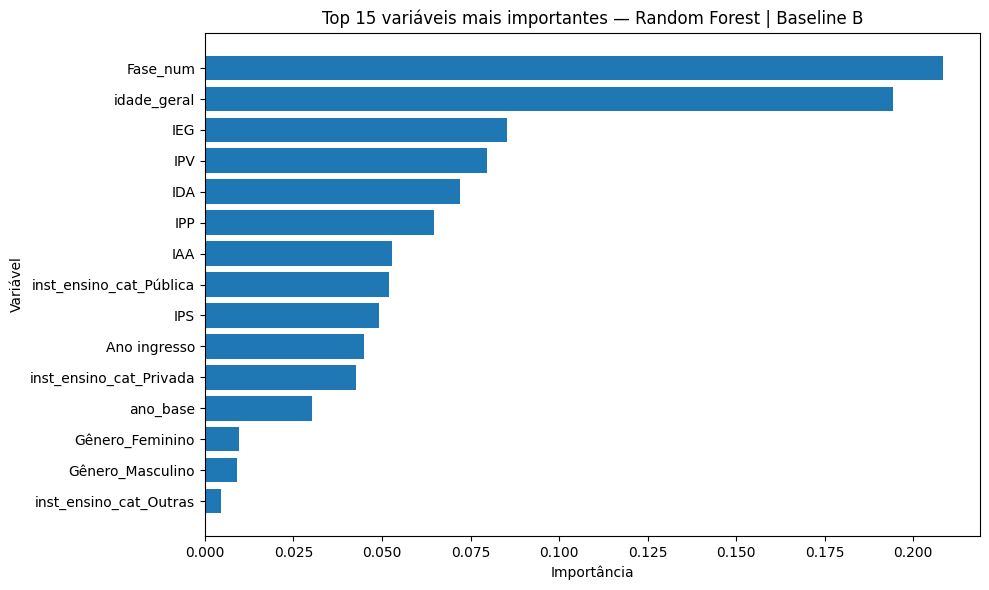

In [45]:
# ============================================================
# BLOCO — GRÁFICO DAS 15 VARIÁVEIS MAIS IMPORTANTES
# ============================================================

import matplotlib.pyplot as plt

top_n = 15
df_plot = df_importancias_rf_B.head(top_n).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(df_plot["variavel"], df_plot["importancia"])
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Top 15 variáveis mais importantes — Random Forest | Baseline B")
plt.tight_layout()
plt.show()

## Conclusão da importância das variáveis — Random Forest | Baseline B

A análise de importância das variáveis mostrou que o modelo **Random Forest** concentra sua capacidade preditiva principalmente em um grupo reduzido de atributos, com destaque para:

- **Fase_num** = **0,21**
- **idade_geral** = **0,19**
- **IEG** = **0,09**
- **IPV** = **0,08**
- **IDA** = **0,07**
- **IPP** = **0,06**
- **IAA** = **0,05**
- **inst_ensino_cat_Pública** = **0,05**
- **IPS** = **0,05**
- **Ano ingresso** = **0,04**

### Interpretação dos resultados

A variável mais importante foi **Fase_num**, indicando que a fase em que o aluno se encontra tem forte relação com a probabilidade de estar em defasagem.

Em seguida, **idade_geral** também apareceu com peso muito alto, sugerindo que a relação entre idade e fase escolar é um dos sinais mais relevantes para o modelo.

Esse resultado faz sentido analítico, porque alunos com idade mais alta para determinada fase tendem a apresentar maior chance de defasagem.

Na sequência, aparecem variáveis ligadas a desempenho, engajamento e trajetória educacional, como:

- **IEG**
- **IPV**
- **IDA**
- **IPP**
- **IAA**
- **IPS**

Isso mostra que o modelo não depende de um único indicador, mas combina informações acadêmicas, comportamentais e contextuais para realizar a previsão.

### Papel das variáveis categóricas

As variáveis ligadas à instituição de ensino tiveram contribuição moderada, com destaque para:

- **inst_ensino_cat_Pública** = **0,05**
- **inst_ensino_cat_Privada** = **0,04**

Já as variáveis de **Gênero** apresentaram importância muito baixa, indicando baixa influência na previsão dentro desta base.

### Conclusão analítica

O resultado mostra que a previsão da defasagem atual está sendo sustentada principalmente por três blocos de informação:

1. **posição escolar do aluno**  
   - especialmente **Fase_num**

2. **características de trajetória e maturidade escolar**  
   - com destaque para **idade_geral** e **Ano ingresso**

3. **indicadores de desempenho e engajamento**  
   - como **IEG**, **IPV**, **IDA**, **IPP**, **IAA** e **IPS**

### Ponto de atenção metodológico

Embora **Fase_num** e **idade_geral** sejam variáveis válidas e não representem vazamento direto como **gap_fase** ou **status_defasagem**, elas parecem carregar uma parte importante da estrutura da defasagem atual.

Isso significa que o modelo está aprendendo sinais consistentes, mas ainda muito associados à condição presente do aluno.

### Próximo passo recomendado

O próximo passo mais importante é avaliar se a modelagem deve:

- continuar refinando a previsão da **defasagem atual**
- ou avançar para um target temporal de **risco futuro**, que represente melhor a proposta da Pergunta 9

Se o objetivo for aproximar mais a análise do conceito de alerta precoce, o ideal é construir um alvo temporal, por exemplo:

- aluno entra em defasagem no ano seguinte
- aluno piora sua condição de defasagem no ano seguinte

## Transição da modelagem para risco futuro

Após concluir o baseline de defasagem atual, a próxima etapa da análise será a construção de um target temporal de **risco futuro**, mais aderente à Pergunta 9.

A ideia é deixar de prever apenas a condição atual do aluno e passar a identificar sinais que antecipem piora no ano seguinte.

Para isso, será utilizada a trajetória do mesmo aluno ao longo do tempo, considerando o vínculo entre:

- **ra_num**
- **ano_base**

O target temporal será construído a partir da comparação entre a situação de defasagem no ano atual e no ano seguinte.

Essa abordagem permite aproximar a modelagem do conceito de alerta precoce, tornando a análise mais consistente com o objetivo de identificar alunos em risco antes do agravamento do problema.

In [46]:
# ============================================================
# BLOCO — PREPARAR BASE TEMPORAL POR ALUNO
# Objetivo:
# - Ordenar a base por aluno e ano
# - Conferir a trajetória temporal
# ============================================================

df_ml_base = df_ml_base.copy()

df_ml_temp = df_ml_base.sort_values(["ra_num", "ano_base"]).reset_index(drop=True)

print("Base temporal criada com sucesso.")
print("Dimensão:", df_ml_temp.shape)

print("\nAmostra ordenada:")
display(
    df_ml_temp[
        ["ra_num", "ano_base", "gap_fase", "status_defasagem"]
    ].head(20)
)

Base temporal criada com sucesso.
Dimensão: (3030, 18)

Amostra ordenada:


,ra_num,ano_base,gap_fase,status_defasagem
0,1,2022,1.00,Em defasagem
1,1,2023,0.00,Sem defasagem
2,1,2024,0.00,Sem defasagem
3,2,2022,0.00,Sem defasagem
4,2,2023,0.00,Sem defasagem
5,2,2024,0.00,Sem defasagem
6,3,2022,0.00,Sem defasagem
7,4,2022,0.00,Sem defasagem
8,5,2022,0.00,Sem defasagem
9,5,2023,0.00,Sem defasagem


In [47]:
# ============================================================
# BLOCO — CRIAR INFORMAÇÕES DO ANO SEGUINTE
# Objetivo:
# - Recuperar, para cada aluno, a situação no ano seguinte
# ============================================================

df_ml_temp = df_ml_temp.copy()

df_ml_temp["ano_base_seguinte"] = df_ml_temp.groupby("ra_num")["ano_base"].shift(-1)
df_ml_temp["gap_fase_seguinte"] = df_ml_temp.groupby("ra_num")["gap_fase"].shift(-1)
df_ml_temp["status_defasagem_seguinte"] = df_ml_temp.groupby("ra_num")["status_defasagem"].shift(-1)

print("Colunas do ano seguinte criadas com sucesso.\n")

display(
    df_ml_temp[
        [
            "ra_num",
            "ano_base",
            "gap_fase",
            "status_defasagem",
            "ano_base_seguinte",
            "gap_fase_seguinte",
            "status_defasagem_seguinte"
        ]
    ].head(20)
)

Colunas do ano seguinte criadas com sucesso.



,ra_num,ano_base,gap_fase,status_defasagem,ano_base_seguinte,gap_fase_seguinte,status_defasagem_seguinte
0,1,2022,1.00,Em defasagem,2023.00,0.00,Sem defasagem
1,1,2023,0.00,Sem defasagem,2024.00,0.00,Sem defasagem
2,1,2024,0.00,Sem defasagem,NaN,NaN,NaN
3,2,2022,0.00,Sem defasagem,2023.00,0.00,Sem defasagem
4,2,2023,0.00,Sem defasagem,2024.00,0.00,Sem defasagem
5,2,2024,0.00,Sem defasagem,NaN,NaN,NaN
6,3,2022,0.00,Sem defasagem,NaN,NaN,NaN
7,4,2022,0.00,Sem defasagem,NaN,NaN,NaN
8,5,2022,0.00,Sem defasagem,2023.00,0.00,Sem defasagem
9,5,2023,0.00,Sem defasagem,NaN,NaN,NaN


In [48]:
# ============================================================
# BLOCO — VALIDAR TRANSIÇÃO TEMPORAL
# Objetivo:
# - Manter apenas casos em que o próximo registro é realmente o ano seguinte
# ============================================================

df_ml_temp = df_ml_temp.copy()

df_ml_temp["tem_proximo_ano"] = df_ml_temp["ano_base_seguinte"] == (df_ml_temp["ano_base"] + 1)

print("Distribuição da validação temporal:")
print(df_ml_temp["tem_proximo_ano"].value_counts(dropna=False))

print("\nAmostra:")
display(
    df_ml_temp[
        [
            "ra_num",
            "ano_base",
            "ano_base_seguinte",
            "tem_proximo_ano"
        ]
    ].head(20)
)

Distribuição da validação temporal:
tem_proximo_ano
False    1665
True     1365
Name: count, dtype: int64

Amostra:


,ra_num,ano_base,ano_base_seguinte,tem_proximo_ano
0,1,2022,2023.00,True
1,1,2023,2024.00,True
2,1,2024,NaN,False
3,2,2022,2023.00,True
4,2,2023,2024.00,True
5,2,2024,NaN,False
6,3,2022,NaN,False
7,4,2022,NaN,False
8,5,2022,2023.00,True
9,5,2023,NaN,False


## Criação do target temporal de risco futuro

Nesta etapa foi criado um novo target voltado à **previsão de risco futuro**, com foco em identificar alunos cuja situação de defasagem piora no ano seguinte.

A construção foi baseada na comparação entre:

- **gap_fase** no ano atual
- **gap_fase_seguinte** no ano seguinte, para o mesmo aluno

### Regra adotada

Foi definido como **risco futuro = 1** quando a situação do aluno piora no ano seguinte, isto é:

- o aluno entra em defasagem
- ou aumenta sua defasagem

Na prática, isso ocorre quando:

- **gap_fase_seguinte > gap_fase**

Nos demais casos, foi definido:

- **target_risco_futuro = 0**

### Interpretação

Essa regra permite tratar como evento de risco qualquer agravamento da trajetória escolar entre dois anos consecutivos, aproximando a análise da proposta de alerta precoce da Pergunta 9.

### Restrição da base

Esse target só pode ser calculado para registros que possuem observação válida no ano seguinte. Por isso, a modelagem temporal utilizará apenas os casos em que:

- **tem_proximo_ano = True**

In [49]:
# ============================================================
# BLOCO — CRIAR TARGET TEMPORAL DE RISCO FUTURO
# Objetivo:
# - Considerar apenas registros com próximo ano válido
# - Criar target_risco_futuro com base no agravamento do gap
# Regra:
# - 1 -> gap_fase_seguinte > gap_fase
# - 0 -> demais casos
# ============================================================

import numpy as np

df_ml_temp = df_ml_temp.copy()

# Manter apenas transições válidas para o próximo ano
df_ml_futuro = df_ml_temp[df_ml_temp["tem_proximo_ano"]].copy()

# Criar target temporal
df_ml_futuro["target_risco_futuro"] = np.where(
    df_ml_futuro["gap_fase_seguinte"] > df_ml_futuro["gap_fase"],
    1,
    0
)

print("Base temporal para risco futuro criada com sucesso.")
print("Dimensão:", df_ml_futuro.shape)

print("\nDistribuição do target_risco_futuro:")
print(df_ml_futuro["target_risco_futuro"].value_counts(dropna=False).sort_index())

print("\nDistribuição percentual:")
print(
    df_ml_futuro["target_risco_futuro"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .round(4)
)

print("\nAmostra para conferência:")
display(
    df_ml_futuro[
        [
            "ra_num",
            "ano_base",
            "gap_fase",
            "gap_fase_seguinte",
            "status_defasagem",
            "status_defasagem_seguinte",
            "target_risco_futuro"
        ]
    ].head(20)
)

Base temporal para risco futuro criada com sucesso.
Dimensão: (1365, 23)

Distribuição do target_risco_futuro:
target_risco_futuro
0    1210
1     155
Name: count, dtype: int64

Distribuição percentual:
target_risco_futuro
0   0.89
1   0.11
Name: proportion, dtype: float64

Amostra para conferência:


,ra_num,ano_base,gap_fase,gap_fase_seguinte,status_defasagem,status_defasagem_seguinte,target_risco_futuro
0,1,2022,1.00,0.00,Em defasagem,Sem defasagem,0
1,1,2023,0.00,0.00,Sem defasagem,Sem defasagem,0
3,2,2022,0.00,0.00,Sem defasagem,Sem defasagem,0
4,2,2023,0.00,0.00,Sem defasagem,Sem defasagem,0
8,5,2022,0.00,0.00,Sem defasagem,Sem defasagem,0
10,6,2022,1.00,0.00,Em defasagem,Sem defasagem,0
11,6,2023,0.00,0.00,Sem defasagem,Sem defasagem,0
13,7,2022,1.00,0.00,Em defasagem,Sem defasagem,0
14,7,2023,0.00,0.00,Sem defasagem,Sem defasagem,0
20,12,2022,0.00,0.00,Sem defasagem,Sem defasagem,0


In [50]:
print("Quantidade de casos com target = 1:")
print((df_ml_futuro["target_risco_futuro"] == 1).sum())

print("\nAmostra de casos com target = 1:")
display(
    df_ml_futuro.loc[
        df_ml_futuro["target_risco_futuro"] == 1,
        [
            "ra_num",
            "ano_base",
            "gap_fase",
            "gap_fase_seguinte",
            "status_defasagem",
            "status_defasagem_seguinte",
            "target_risco_futuro"
        ]
    ].head(20)
)

Quantidade de casos com target = 1:
155

Amostra de casos com target = 1:


,ra_num,ano_base,gap_fase,gap_fase_seguinte,status_defasagem,status_defasagem_seguinte,target_risco_futuro
44,23,2023,-1.00,0.00,Acima do ideal,Sem defasagem,1
86,42,2022,0.00,1.00,Sem defasagem,Em defasagem,1
96,46,2022,2.00,3.00,Em defasagem,Em defasagem,1
107,52,2022,-2.00,-1.00,Acima do ideal,Acima do ideal,1
143,70,2022,1.00,2.00,Em defasagem,Em defasagem,1
163,81,2022,-1.00,0.00,Acima do ideal,Sem defasagem,1
170,85,2022,0.00,1.00,Sem defasagem,Em defasagem,1
171,85,2023,1.00,2.00,Em defasagem,Em defasagem,1
184,90,2022,-2.00,-1.00,Acima do ideal,Acima do ideal,1
196,94,2022,0.00,1.00,Sem defasagem,Em defasagem,1


In [51]:
pd.crosstab(
    df_ml_futuro["gap_fase"],
    df_ml_futuro["gap_fase_seguinte"],
    margins=True
)

gap_fase_seguinte,-2.00,-1.00,0.00,1.00,2.00,3.00,4.00,All
gap_fase,,,,,,,,
-2.00,1,7,0,0,0,0,0,8
-1.00,6,14,14,1,0,0,0,35
0.00,11,86,217,64,1,0,0,379
1.00,3,3,287,317,63,0,0,673
2.00,0,0,25,148,76,5,0,254
3.00,0,2,0,0,9,3,0,14
4.00,0,0,0,0,0,1,1,2
All,21,112,543,530,149,9,1,1365


## Preparação da base para modelagem de risco futuro

Com o target temporal já definido, o próximo passo é preparar a base que será usada na modelagem preditiva de **risco futuro**.

Nesta etapa, serão mantidas apenas as variáveis do **ano atual** que podem servir como sinais antecedentes da piora no ano seguinte.

### Critério adotado

Serão removidas da base:

- variáveis identificadoras
- variáveis que representam diretamente o ano seguinte
- variáveis criadas apenas para controle da transição temporal
- o próprio target

Além disso, nesta primeira versão da modelagem temporal, também serão excluídas as variáveis **gap_fase** e **status_defasagem**, para evitar que a previsão fique excessivamente dependente da condição atual já resumida em uma variável de defasagem.

### Objetivo

O objetivo é construir uma base mais conservadora e analiticamente mais limpa, focada em prever agravamento futuro a partir de indicadores acadêmicos, comportamentais e cadastrais do ano atual.

In [52]:
# ============================================================
# BLOCO — CRIAR BASE DE MODELAGEM PARA RISCO FUTURO
# Objetivo:
# - Montar base limpa para prever target_risco_futuro
# - Remover identificadores, colunas do ano seguinte e colunas de controle
# - Excluir gap_fase e status_defasagem nesta primeira versão
# ============================================================

df_ml_futuro = df_ml_futuro.copy()

colunas_excluir_futuro = [
    "ra_num",
    "ano_base_seguinte",
    "gap_fase_seguinte",
    "status_defasagem_seguinte",
    "tem_proximo_ano",
    "target_risco_futuro",
    "gap_fase",
    "status_defasagem"
]

X_futuro = df_ml_futuro.drop(columns=colunas_excluir_futuro, errors="ignore").copy()
y_futuro = df_ml_futuro["target_risco_futuro"].copy()

print("X_futuro criado com sucesso.")
print("Dimensão de X_futuro:", X_futuro.shape)

print("\ny_futuro criado com sucesso.")
print("Dimensão de y_futuro:", y_futuro.shape)

print("\nColunas de X_futuro:")
print(X_futuro.columns.tolist())

print("\nDistribuição de y_futuro:")
print(y_futuro.value_counts(dropna=False).sort_index())

print("\nDistribuição percentual de y_futuro:")
print(
    y_futuro.value_counts(normalize=True, dropna=False)
    .sort_index()
    .round(4)
)

X_futuro criado com sucesso.
Dimensão de X_futuro: (1365, 15)

y_futuro criado com sucesso.
Dimensão de y_futuro: (1365,)

Colunas de X_futuro:
['ano_base', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num', 'FaseIdeal_num', 'target_defasagem_atual']

Distribuição de y_futuro:
target_risco_futuro
0    1210
1     155
Name: count, dtype: int64

Distribuição percentual de y_futuro:
target_risco_futuro
0   0.89
1   0.11
Name: proportion, dtype: float64


## Preparação da modelagem para risco futuro

Com a base de risco futuro já separada em **X_futuro** e **y_futuro**, a próxima etapa é preparar os dados para o treinamento dos modelos.

Nesta etapa, serão realizados:

- diagnóstico estrutural da base
- divisão entre treino e teste com estratificação
- identificação das variáveis numéricas e categóricas
- criação do pipeline de pré-processamento

Como o target de risco futuro apresenta desbalanceamento entre as classes, essa característica será considerada nas próximas etapas da modelagem.

In [54]:
# ============================================================
# BLOCO — DIAGNÓSTICO DA BASE DE RISCO FUTURO
# Objetivo:
# - Verificar dimensão, tipos, nulos e categóricas
# - Conferir a distribuição do target
# ============================================================

import pandas as pd

print("=" * 100)
print("DIAGNÓSTICO: BASE DE RISCO FUTURO")
print("=" * 100)

print("\nDimensão de X_futuro:")
print(X_futuro.shape)

print("\nTipos das colunas:")
print(X_futuro.dtypes)

nulos = X_futuro.isna().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]

print("\nColunas com nulos:")
if len(nulos) == 0:
    print("Nenhuma coluna com nulos.")
else:
    resumo_nulos = pd.DataFrame({
        "qtd_nulos": nulos,
        "perc_nulos": (nulos / len(X_futuro) * 100).round(2)
    })
    print(resumo_nulos)

cat_cols_futuro = X_futuro.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("\nColunas categóricas:")
print(cat_cols_futuro)

print("\nDistribuição de y_futuro:")
print(y_futuro.value_counts(dropna=False).sort_index())

print("\nDistribuição percentual de y_futuro:")
print(
    y_futuro.value_counts(normalize=True, dropna=False)
    .sort_index()
    .round(4)
)

DIAGNÓSTICO: BASE DE RISCO FUTURO

Dimensão de X_futuro:
(1365, 15)

Tipos das colunas:
ano_base                           int64
IAN                              float64
IDA                              float64
IEG                              float64
IAA                              float64
IPS                              float64
IPP                              float64
IPV                              float64
idade_geral                        Int64
Gênero                    string[python]
Ano ingresso                       int64
inst_ensino_cat                   object
Fase_num                         float64
FaseIdeal_num                      int64
target_defasagem_atual             int64
dtype: object

Colunas com nulos:
     qtd_nulos  perc_nulos
IPP        672       49.23
IEG         72        5.27
IDA         72        5.27
IPV         72        5.27
IPS         62        4.54
IAA         59        4.32

Colunas categóricas:
['Gênero', 'inst_ensino_cat']

Distribuição de y_fut

In [55]:
# ============================================================
# BLOCO — SPLIT + PRÉ-PROCESSAMENTO DA BASE DE RISCO FUTURO
# Objetivo:
# - Separar treino e teste
# - Identificar colunas numéricas e categóricas
# - Montar preprocessador
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# 1. Split estratificado
# ------------------------------------------------------------
X_train_fut, X_test_fut, y_train_fut, y_test_fut = train_test_split(
    X_futuro,
    y_futuro,
    test_size=0.2,
    random_state=42,
    stratify=y_futuro
)

print("Split realizado com sucesso.")
print("X_train_fut:", X_train_fut.shape)
print("X_test_fut :", X_test_fut.shape)
print("y_train_fut:", y_train_fut.shape)
print("y_test_fut :", y_test_fut.shape)

# ------------------------------------------------------------
# 2. Identificar colunas
# ------------------------------------------------------------
colunas_cat_fut = X_train_fut.select_dtypes(include=["object", "category", "string"]).columns.tolist()
colunas_num_fut = X_train_fut.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

print("\nColunas categóricas:")
print(colunas_cat_fut)

print("\nColunas numéricas:")
print(colunas_num_fut)

# ------------------------------------------------------------
# 3. Pipeline numérico
# ------------------------------------------------------------
pipeline_num_fut = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------------------------------------------------
# 4. Pipeline categórico
# ------------------------------------------------------------
pipeline_cat_fut = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ------------------------------------------------------------
# 5. Preprocessador final
# ------------------------------------------------------------
preprocessador_fut = ColumnTransformer(transformers=[
    ("num", pipeline_num_fut, colunas_num_fut),
    ("cat", pipeline_cat_fut, colunas_cat_fut)
])

print("\nPreprocessador_fut criado com sucesso.")

Split realizado com sucesso.
X_train_fut: (1092, 15)
X_test_fut : (273, 15)
y_train_fut: (1092,)
y_test_fut : (273,)

Colunas categóricas:
['Gênero', 'inst_ensino_cat']

Colunas numéricas:
['ano_base', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Ano ingresso', 'Fase_num', 'FaseIdeal_num', 'target_defasagem_atual']

Preprocessador_fut criado com sucesso.


In [56]:
# ============================================================
# BLOCO — REGRESSÃO LOGÍSTICA | RISCO FUTURO
# Objetivo:
# - Treinar modelo inicial para prever risco futuro
# - Considerar desbalanceamento com class_weight="balanced"
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

modelo_logit_fut = Pipeline(steps=[
    ("preprocessador", preprocessador_fut),
    ("modelo", LogisticRegression(
        max_iter=5000,
        random_state=42,
        class_weight="balanced"
    ))
])

modelo_logit_fut.fit(X_train_fut, y_train_fut)

y_pred_fut = modelo_logit_fut.predict(X_test_fut)

acc_fut = accuracy_score(y_test_fut, y_pred_fut)
matriz_fut = confusion_matrix(y_test_fut, y_pred_fut)
relatorio_fut = classification_report(y_test_fut, y_pred_fut)

print("RESULTADOS — REGRESSÃO LOGÍSTICA | RISCO FUTURO")
print("=" * 70)

print(f"\nAcurácia: {acc_fut:.4f}")

print("\nMatriz de confusão:")
print(matriz_fut)

print("\nRelatório de classificação:")
print(relatorio_fut)

RESULTADOS — REGRESSÃO LOGÍSTICA | RISCO FUTURO

Acurácia: 0.7582

Matriz de confusão:
[[180  62]
 [  4  27]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.98      0.74      0.85       242
           1       0.30      0.87      0.45        31

    accuracy                           0.76       273
   macro avg       0.64      0.81      0.65       273
weighted avg       0.90      0.76      0.80       273



## Conclusão inicial da Regressão Logística — Risco futuro

O primeiro modelo treinado para prever **risco futuro de agravamento da defasagem** apresentou desempenho moderado em termos de acurácia geral, mas com um resultado importante do ponto de vista analítico: conseguiu identificar a maior parte dos casos positivos.

### Resultado obtido

- **acurácia = 0,7582**

Matriz de confusão:

- verdadeiros negativos: **180**
- falsos positivos: **62**
- falsos negativos: **4**
- verdadeiros positivos: **27**

Relatório de classificação:

- classe **0**:
  - precision = **0,98**
  - recall = **0,74**
  - f1-score = **0,85**
- classe **1**:
  - precision = **0,30**
  - recall = **0,87**
  - f1-score = **0,45**

### Interpretação

O principal destaque está no **recall da classe 1**, igual a **0,87**. Isso significa que o modelo conseguiu capturar a maior parte dos alunos que realmente apresentaram piora no ano seguinte.

Esse comportamento é relevante porque, em um contexto de **alerta precoce**, costuma ser mais importante reduzir os falsos negativos do que maximizar a acurácia geral.

Em outras palavras, o modelo mostrou boa sensibilidade para detectar risco futuro, ainda que com geração de falsos positivos em quantidade elevada.

### Limitação observada

A **precision da classe 1**, igual a **0,30**, mostra que parte significativa dos alertas emitidos pelo modelo não se concretiza em agravamento real no ano seguinte.

Isso indica que o modelo, neste estágio inicial, funciona melhor como ferramenta de **triagem** do que como instrumento de decisão final.

### Conclusão analítica

Os resultados sugerem que a base possui sinal preditivo para antecipar agravamento futuro, mas ainda exige refinamento para melhorar a precisão dos alertas.

Mesmo assim, esta etapa já representa um avanço importante em relação ao baseline de defasagem atual, pois passa a trabalhar com uma lógica temporal mais aderente à Pergunta 9.

### Próximo passo recomendado

O próximo passo mais indicado é testar um modelo não linear, como **Random Forest**, para verificar se ele consegue manter boa sensibilidade para os casos positivos e, ao mesmo tempo, reduzir a quantidade de falsos positivos.

## Teste do Random Forest para risco futuro

Após o primeiro teste com Regressão Logística, o próximo passo é avaliar o desempenho de um modelo não linear na previsão de **risco futuro**: o **Random Forest**.

A proposta é verificar se esse modelo consegue capturar padrões mais complexos entre os indicadores do ano atual e, com isso, melhorar a identificação de alunos que pioram no ano seguinte.

Como o problema apresenta desbalanceamento entre as classes, a análise do modelo deverá considerar não apenas a acurácia, mas também métricas como:

- precision da classe positiva
- recall da classe positiva
- f1-score da classe positiva

Essas métricas são mais adequadas para avaliar a utilidade do modelo em um cenário de alerta precoce.

In [57]:
# ============================================================
# BLOCO — RANDOM FOREST | RISCO FUTURO
# Objetivo:
# - Treinar Random Forest para prever risco futuro
# - Comparar com a Regressão Logística
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_rf_fut = Pipeline(steps=[
    ("preprocessador", preprocessador_fut),
    ("modelo", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# Treinamento
modelo_rf_fut.fit(X_train_fut, y_train_fut)

# Predição
y_pred_rf_fut = modelo_rf_fut.predict(X_test_fut)

# Avaliação
acc_rf_fut = accuracy_score(y_test_fut, y_pred_rf_fut)
matriz_rf_fut = confusion_matrix(y_test_fut, y_pred_rf_fut)
relatorio_rf_fut = classification_report(y_test_fut, y_pred_rf_fut)

print("RESULTADOS — RANDOM FOREST | RISCO FUTURO")
print("=" * 70)

print(f"\nAcurácia: {acc_rf_fut:.4f}")

print("\nMatriz de confusão:")
print(matriz_rf_fut)

print("\nRelatório de classificação:")
print(relatorio_rf_fut)

RESULTADOS — RANDOM FOREST | RISCO FUTURO

Acurácia: 0.9048

Matriz de confusão:
[[238   4]
 [ 22   9]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       242
           1       0.69      0.29      0.41        31

    accuracy                           0.90       273
   macro avg       0.80      0.64      0.68       273
weighted avg       0.89      0.90      0.89       273



In [58]:
# ============================================================
# BLOCO — COMPARAÇÃO: LOGÍSTICA x RANDOM FOREST | RISCO FUTURO
# Objetivo:
# - Comparar os dois modelos no target temporal
# ============================================================

print("COMPARAÇÃO DE MODELOS — RISCO FUTURO")
print("=" * 70)
print(f"Regressão Logística : {acc_fut:.4f}")
print(f"Random Forest       : {acc_rf_fut:.4f}")

if acc_rf_fut > acc_fut:
    print("\nLeitura inicial: o Random Forest teve maior acurácia.")
elif acc_rf_fut < acc_fut:
    print("\nLeitura inicial: a Regressão Logística teve maior acurácia.")
else:
    print("\nLeitura inicial: os dois modelos tiveram a mesma acurácia.")

COMPARAÇÃO DE MODELOS — RISCO FUTURO
Regressão Logística : 0.7582
Random Forest       : 0.9048

Leitura inicial: o Random Forest teve maior acurácia.


## Conclusão da comparação entre Regressão Logística e Random Forest — Risco futuro

A comparação entre os dois modelos mostrou comportamentos bastante diferentes na previsão de **risco futuro**.

### Regressão Logística

A Regressão Logística apresentou:

- **acurácia = 0,7582**
- **precision da classe 1 = 0,30**
- **recall da classe 1 = 0,87**
- **f1-score da classe 1 = 0,45**

Esse resultado mostra que o modelo conseguiu identificar a maior parte dos alunos que realmente pioraram no ano seguinte, embora com geração de muitos falsos positivos.

### Random Forest

O Random Forest apresentou:

- **acurácia = 0,9048**
- **precision da classe 1 = 0,69**
- **recall da classe 1 = 0,29**
- **f1-score da classe 1 = 0,41**

Embora tenha alcançado acurácia geral mais alta, esse desempenho foi fortemente influenciado pela boa classificação da classe majoritária, ou seja, dos casos sem agravamento.

Para a classe positiva, que representa os alunos em risco futuro, o modelo teve baixa sensibilidade e deixou de identificar grande parte dos casos reais.

### Interpretação comparativa

Os resultados indicam que:

- a **Regressão Logística** é mais sensível para detectar alunos em risco
- o **Random Forest** é mais conservador e gera menos falsos positivos, mas perde muitos casos positivos reais

### Conclusão analítica

Considerando o objetivo da **Pergunta 9**, que é identificar padrões capazes de antecipar risco antes do agravamento da defasagem, a **Regressão Logística se mostra mais adequada neste estágio**, mesmo com acurácia geral menor.

Isso ocorre porque, em um cenário de alerta precoce, o mais importante é reduzir a perda de casos de risco real, e não apenas maximizar a acurácia total.

### Síntese final

- **se o foco for sensibilidade e triagem preventiva:** a melhor escolha é a **Regressão Logística**
- **se o foco for emitir menos alertas falsos:** o **Random Forest** é mais conservador, mas menos aderente ao objetivo da Pergunta 9

## Ajuste do limiar de decisão na Regressão Logística

Após comparar os modelos para risco futuro, a Regressão Logística foi mantida como principal candidata por apresentar maior capacidade de identificar os casos positivos.

Nesta etapa, o objetivo é ajustar o **limiar de decisão** do modelo.

Por padrão, a classificação binária considera:

- probabilidade maior ou igual a **0,50** → classe 1
- probabilidade menor que **0,50** → classe 0

No entanto, em problemas de **alerta precoce**, esse valor padrão pode não ser o mais adequado.

### Objetivo do ajuste

O objetivo é avaliar diferentes limiares para encontrar um ponto de equilíbrio mais adequado entre:

- **recall da classe positiva**  
  capacidade de capturar os alunos que realmente vão piorar

- **precision da classe positiva**  
  proporção de alertas que realmente correspondem a casos de agravamento

Essa análise ajuda a adaptar o modelo ao propósito da Pergunta 9, priorizando sensibilidade sem perder totalmente a utilidade prática dos alertas.

In [60]:
# ============================================================
# BLOCO — TESTAR LIMIARES DE DECISÃO | REGRESSÃO LOGÍSTICA
# Objetivo:
# - Avaliar diferentes thresholds para a classe 1
# - Comparar precision, recall e f1-score
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Probabilidade da classe 1
y_prob_fut = modelo_logit_fut.predict_proba(X_test_fut)[:, 1]

# Lista de limiares para teste
limiares = np.arange(0.10, 0.91, 0.05)

resultados_limiares = []

for limiar in limiares:
    y_pred_limiar = (y_prob_fut >= limiar).astype(int)

    resultados_limiares.append({
        "limiar": round(limiar, 2),
        "acuracia": round(accuracy_score(y_test_fut, y_pred_limiar), 4),
        "precision_classe_1": round(precision_score(y_test_fut, y_pred_limiar, zero_division=0), 4),
        "recall_classe_1": round(recall_score(y_test_fut, y_pred_limiar, zero_division=0), 4),
        "f1_classe_1": round(f1_score(y_test_fut, y_pred_limiar, zero_division=0), 4),
        "alertas_emitidos": int(y_pred_limiar.sum())
    })

df_limiares = pd.DataFrame(resultados_limiares)

print("Avaliação de limiares concluída.\n")
display(df_limiares)

Avaliação de limiares concluída.



,limiar,acuracia,precision_classe_1,recall_classe_1,f1_classe_1,alertas_emitidos
0,0.10,0.29,0.13,0.97,0.24,223
1,0.15,0.37,0.15,0.97,0.26,201
2,0.20,0.44,0.16,0.97,0.28,183
3,0.25,0.50,0.18,0.97,0.30,166
4,0.30,0.58,0.21,0.94,0.34,141
5,0.35,0.63,0.22,0.90,0.36,126
6,0.40,0.69,0.25,0.87,0.39,108
7,0.45,0.71,0.27,0.87,0.41,101
8,0.50,0.76,0.30,0.87,0.45,89
9,0.55,0.78,0.32,0.84,0.46,82


## Conclusão do ajuste de limiar — Regressão Logística | Risco futuro

A avaliação de diferentes limiares mostrou que o valor padrão de **0,50** não é necessariamente o ponto mais adequado para o objetivo da Pergunta 9.

### Comportamento observado

À medida que o limiar aumenta:

- a **precision da classe 1** cresce
- o **recall da classe 1** diminui
- a quantidade de alertas emitidos também diminui

Esse comportamento mostra o trade-off clássico entre:

- **capturar mais casos de risco**
- **emitir alertas mais confiáveis**

### Escolha recomendada

Para esta análise, o limiar **0,70** se mostrou um ponto de equilíbrio mais adequado, apresentando:

- **acurácia = 0,88**
- **precision da classe 1 = 0,47**
- **recall da classe 1 = 0,68**
- **f1-score da classe 1 = 0,55**
- **45 alertas emitidos**

### Interpretação

Esse limiar reduz de forma importante a quantidade de falsos positivos em comparação com o valor padrão de 0,50, ao mesmo tempo em que mantém capacidade relevante de identificar alunos que realmente pioram no ano seguinte.

Assim, o modelo deixa de funcionar apenas como triagem ampla e passa a emitir alertas com melhor equilíbrio entre sensibilidade e utilidade prática.

### Conclusão final

Diante dos resultados observados, o limiar **0,70** é o ponto mais recomendado para continuidade da análise, por oferecer melhor equilíbrio entre:

- capacidade de antecipar risco
- qualidade dos alertas emitidos
- aderência prática à proposta de alerta precoce da Pergunta 9

In [61]:
# ============================================================
# BLOCO — AVALIAÇÃO FINAL COM LIMIAR 0.70
# Objetivo:
# - Aplicar o limiar recomendado
# - Exibir matriz e relatório final
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

limiar_final = 0.70

y_pred_fut_final = (y_prob_fut >= limiar_final).astype(int)

acc_fut_final = accuracy_score(y_test_fut, y_pred_fut_final)
matriz_fut_final = confusion_matrix(y_test_fut, y_pred_fut_final)
relatorio_fut_final = classification_report(y_test_fut, y_pred_fut_final)

print(f"RESULTADOS FINAIS — REGRESSÃO LOGÍSTICA | RISCO FUTURO | LIMIAR = {limiar_final}")
print("=" * 85)

print(f"\nAcurácia: {acc_fut_final:.4f}")

print("\nMatriz de confusão:")
print(matriz_fut_final)

print("\nRelatório de classificação:")
print(relatorio_fut_final)

RESULTADOS FINAIS — REGRESSÃO LOGÍSTICA | RISCO FUTURO | LIMIAR = 0.7

Acurácia: 0.8755

Matriz de confusão:
[[218  24]
 [ 10  21]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       242
           1       0.47      0.68      0.55        31

    accuracy                           0.88       273
   macro avg       0.71      0.79      0.74       273
weighted avg       0.90      0.88      0.89       273



## Conclusão final da Regressão Logística ajustada por limiar — Risco futuro

Após o teste de diferentes limiares de decisão, o valor **0,70** foi adotado como ponto de equilíbrio mais adequado para a previsão de **risco futuro**.

### Resultado final com limiar 0,70

O modelo apresentou:

- **acurácia = 0,8755**

Matriz de confusão:

- verdadeiros negativos: **218**
- falsos positivos: **24**
- falsos negativos: **10**
- verdadeiros positivos: **21**

Relatório de classificação:

- classe **0**:
  - precision = **0,96**
  - recall = **0,90**
  - f1-score = **0,93**
- classe **1**:
  - precision = **0,47**
  - recall = **0,68**
  - f1-score = **0,55**

### Interpretação

O ajuste do limiar permitiu melhorar o equilíbrio entre sensibilidade e utilidade prática dos alertas.

Em comparação com o limiar padrão de **0,50**, houve redução importante na quantidade de falsos positivos, sem perda excessiva da capacidade de identificar os alunos que realmente pioram no ano seguinte.

Assim, o modelo passou a operar de forma mais equilibrada:

- mantém capacidade relevante de detectar risco futuro
- reduz a emissão de alertas excessivos
- melhora a interpretabilidade prática da saída

### Conclusão analítica

O resultado com limiar **0,70** mostra que a **Regressão Logística** pode ser utilizada como um modelo de **alerta precoce ajustado**, mais aderente à proposta da Pergunta 9.

Esse modelo não pretende fornecer certeza absoluta sobre agravamento futuro, mas sim apoiar a identificação antecipada de alunos com maior probabilidade de piora, permitindo ações preventivas mais direcionadas.

### Síntese final

A configuração final com limiar **0,70** apresentou o melhor equilíbrio observado até o momento entre:

- capacidade de antecipar risco
- qualidade dos alertas emitidos
- aderência prática ao objetivo do estudo

## Interpretação do modelo final de risco futuro

Após a definição da **Regressão Logística com limiar 0,70** como modelo final mais adequado para a previsão de risco futuro, inicia-se uma nova etapa da análise.

Até aqui, o foco foi identificar **qual modelo apresentou o melhor equilíbrio entre acurácia, recall, precision e f1-score da classe positiva**, de modo aderente à proposta de alerta precoce da Pergunta 9.

Com essa etapa concluída, o objetivo agora deixa de ser comparar modelos e passa a ser **interpretar o modelo já escolhido**.

Na prática, isso significa abrir a estrutura interna da Regressão Logística para responder perguntas como:

- quais variáveis mais aumentam a chance de agravamento no ano seguinte
- quais variáveis mais reduzem essa chance
- quais fatores têm maior peso na decisão do modelo

Essa etapa é importante porque a Pergunta 9 não exige apenas um modelo preditivo com bom desempenho. Ela também pede compreensão sobre os **padrões nos indicadores** que ajudam a antecipar risco.

Por esse motivo, os próximos blocos não vão treinar um novo modelo.  
Eles vão apenas:

- recuperar o pipeline já treinado
- extrair os coeficientes da Regressão Logística final
- relacionar esses coeficientes às variáveis usadas no modelo
- organizar a leitura analítica dos sinais de risco e proteção

Em resumo, a etapa anterior definiu **qual modelo usar**.  
A etapa seguinte busca entender **o que esse modelo aprendeu** e **quais variáveis estão sustentando suas previsões**.

## Etapa 1 — Recuperar o preprocessador e o modelo final

Nesta etapa vamos acessar os dois componentes principais do pipeline já treinado:

- **preprocessador**: responsável por imputação, padronização e transformação das variáveis
- **modelo**: a Regressão Logística já ajustada na base de risco futuro

Isso é necessário porque os coeficientes não ficam diretamente acessíveis no pipeline inteiro.  
Primeiro precisamos separar o pipeline em suas partes para depois enxergar os nomes finais das variáveis e os pesos aprendidos pelo modelo.

In [68]:
# ============================================================
# ETAPA 1 — RECUPERAR PREPROCESSADOR E MODELO FINAL
# Objetivo:
# - Separar do pipeline o preprocessador e o modelo treinado
# ============================================================

preprocessador_final = modelo_logit_fut.named_steps["preprocessador"]
modelo_final = modelo_logit_fut.named_steps["modelo"]

print("Preprocessador recuperado com sucesso.")
print("Modelo final recuperado com sucesso.")
print("\nTipo do preprocessador:", type(preprocessador_final))
print("Tipo do modelo:", type(modelo_final))

Preprocessador recuperado com sucesso.
Modelo final recuperado com sucesso.

Tipo do preprocessador: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Tipo do modelo: <class 'sklearn.linear_model._logistic.LogisticRegression'>


## Etapa 2 — Recuperar os nomes finais das variáveis após o pré-processamento

A Regressão Logística não trabalha diretamente com os nomes originais das colunas quando há transformação no pipeline.

Como foram aplicados:

- imputação de nulos
- padronização de variáveis numéricas
- one-hot encoding nas variáveis categóricas

o modelo passou a enxergar uma versão transformada da base.

Nesta etapa, vamos recuperar os nomes finais dessas variáveis transformadas.  
Isso é essencial para sabermos a que cada coeficiente do modelo realmente corresponde.

In [69]:
# ============================================================
# ETAPA 2 — RECUPERAR NOMES DAS VARIÁVEIS TRANSFORMADAS
# Objetivo:
# - Obter os nomes finais usados pelo modelo após o preprocessamento
# ============================================================

nomes_variaveis_finais = preprocessador_final.get_feature_names_out()

print("Quantidade de variáveis transformadas:", len(nomes_variaveis_finais))
print("\nAmostra dos nomes finais:")
for nome in nomes_variaveis_finais[:20]:
    print(nome)

Quantidade de variáveis transformadas: 18

Amostra dos nomes finais:
num__ano_base
num__IAN
num__IDA
num__IEG
num__IAA
num__IPS
num__IPP
num__IPV
num__idade_geral
num__Ano ingresso
num__Fase_num
num__FaseIdeal_num
num__target_defasagem_atual
cat__Gênero_Feminino
cat__Gênero_Masculino
cat__inst_ensino_cat_Outras
cat__inst_ensino_cat_Privada
cat__inst_ensino_cat_Pública


## Etapa 3 — Extrair os coeficientes do modelo

Na Regressão Logística, cada variável recebe um coeficiente.

A interpretação geral é:

- coeficiente **positivo**: aumenta a chance de risco futuro
- coeficiente **negativo**: reduz a chance de risco futuro
- quanto maior o valor absoluto, maior a influência da variável no modelo

Nesta etapa, vamos extrair os coeficientes diretamente do modelo treinado.

In [70]:
# ============================================================
# ETAPA 3 — EXTRAIR COEFICIENTES DO MODELO
# Objetivo:
# - Extrair os pesos aprendidos pela Regressão Logística
# ============================================================

coeficientes = modelo_final.coef_[0]

print("Quantidade de coeficientes extraídos:", len(coeficientes))
print("\nPrimeiros coeficientes:")
print(coeficientes[:20])

Quantidade de coeficientes extraídos: 18

Primeiros coeficientes:
[-1.30735426e-01 -1.81967990e+00 -3.43961587e-01  3.25390828e-03
 -1.22893073e-01  7.08316670e-02 -3.22141004e-01 -6.56327535e-01
 -4.28177964e-01  2.66215857e-01  3.65942861e+00 -3.24911425e+00
 -1.42985440e+00  8.60181377e-02 -8.34537146e-02 -4.21652630e-01
 -1.08189295e-01  5.32406348e-01]


## Etapa 4 — Montar a tabela de coeficientes

Agora vamos juntar em uma única tabela:

- nome da variável transformada
- coeficiente do modelo

Isso permite visualizar cada peso de forma organizada e preparar a análise posterior.

In [71]:
# ============================================================
# ETAPA 4 — MONTAR DATAFRAME DE COEFICIENTES
# Objetivo:
# - Unir nomes das variáveis e coeficientes em uma tabela
# ============================================================

df_coeficientes = pd.DataFrame({
    "variavel_transformada": nomes_variaveis_finais,
    "coeficiente": coeficientes
})

print("DataFrame de coeficientes criado com sucesso.")
print("\nDimensão:", df_coeficientes.shape)
display(df_coeficientes.head(20))

DataFrame de coeficientes criado com sucesso.

Dimensão: (18, 2)


,variavel_transformada,coeficiente
0,num__ano_base,-0.13
1,num__IAN,-1.82
2,num__IDA,-0.34
3,num__IEG,0.00
4,num__IAA,-0.12
5,num__IPS,0.07
6,num__IPP,-0.32
7,num__IPV,-0.66
8,num__idade_geral,-0.43
9,num__Ano ingresso,0.27


## Etapa 5 — Limpar os nomes das variáveis

Os nomes recuperados do pipeline costumam vir com prefixos técnicos, como:

- **num__**
- **cat__**

Esses prefixos apenas indicam se a variável veio do bloco numérico ou categórico do preprocessamento.

Nesta etapa, vamos remover esses prefixos para deixar a leitura mais limpa e mais fácil de interpretar no relatório.

In [73]:
# ============================================================
# ETAPA 5 — LIMPAR NOMES DAS VARIÁVEIS
# Objetivo:
# - Remover prefixos técnicos do preprocessamento
# ============================================================

df_coeficientes["variavel"] = (
    df_coeficientes["variavel_transformada"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(df_coeficientes[["variavel_transformada", "variavel", "coeficiente"]].head(20))

,variavel_transformada,variavel,coeficiente
0,num__ano_base,ano_base,-0.13
1,num__IAN,IAN,-1.82
2,num__IDA,IDA,-0.34
3,num__IEG,IEG,0.00
4,num__IAA,IAA,-0.12
5,num__IPS,IPS,0.07
6,num__IPP,IPP,-0.32
7,num__IPV,IPV,-0.66
8,num__idade_geral,idade_geral,-0.43
9,num__Ano ingresso,Ano ingresso,0.27


## Etapa 6 — Criar medidas auxiliares de interpretação

Além do coeficiente bruto, vamos calcular duas medidas auxiliares:

### 1. Coeficiente absoluto
Mostra a intensidade do efeito, sem considerar se ele é positivo ou negativo.

### 2. Odds ratio
É a exponenciação do coeficiente e ajuda na interpretação prática:

- **maior que 1** → aumenta a chance de risco
- **menor que 1** → reduz a chance de risco
- **igual a 1** → efeito praticamente neutro

Essas medidas ajudam a organizar melhor a leitura do modelo.

In [74]:
# ============================================================
# ETAPA 6 — CRIAR MEDIDAS AUXILIARES
# Objetivo:
# - Calcular coeficiente absoluto
# - Calcular odds ratio
# ============================================================

df_coeficientes["coef_abs"] = df_coeficientes["coeficiente"].abs()
df_coeficientes["odds_ratio"] = np.exp(df_coeficientes["coeficiente"])

display(df_coeficientes.head(20))

,variavel_transformada,coeficiente,variavel,coef_abs,odds_ratio
0,num__ano_base,-0.13,ano_base,0.13,0.88
1,num__IAN,-1.82,IAN,1.82,0.16
2,num__IDA,-0.34,IDA,0.34,0.71
3,num__IEG,0.00,IEG,0.00,1.00
4,num__IAA,-0.12,IAA,0.12,0.88
5,num__IPS,0.07,IPS,0.07,1.07
6,num__IPP,-0.32,IPP,0.32,0.72
7,num__IPV,-0.66,IPV,0.66,0.52
8,num__idade_geral,-0.43,idade_geral,0.43,0.65
9,num__Ano ingresso,0.27,Ano ingresso,0.27,1.31


## Etapa 7 — Ordenar as variáveis para análise

Agora vamos gerar três visões complementares:

### 1. Maiores coeficientes positivos
Mostram as variáveis mais associadas ao aumento do risco futuro.

### 2. Maiores coeficientes negativos
Mostram as variáveis mais associadas à redução do risco futuro.

### 3. Maior impacto absoluto
Mostram as variáveis mais influentes no modelo, independentemente da direção do efeito.

In [75]:
# ============================================================
# ETAPA 7 — ORDENAR AS VARIÁVEIS
# Objetivo:
# - Criar visões ordenadas para interpretação
# ============================================================

df_coef_ordenado_positivo = df_coeficientes.sort_values(
    by="coeficiente",
    ascending=False
).reset_index(drop=True)

df_coef_ordenado_negativo = df_coeficientes.sort_values(
    by="coeficiente",
    ascending=True
).reset_index(drop=True)

df_coef_impacto = df_coeficientes.sort_values(
    by="coef_abs",
    ascending=False
).reset_index(drop=True)

print("Tabelas ordenadas criadas com sucesso.")

Tabelas ordenadas criadas com sucesso.


## Etapa 8 — Exibir os resultados principais

Nesta etapa vamos mostrar:

- variáveis que mais aumentam o risco futuro
- variáveis que mais reduzem o risco futuro
- variáveis de maior impacto absoluto

Essas três tabelas formam a base da interpretação analítica do modelo final.

In [79]:
# ============================================================
# ETAPA 8 — EXIBIR RESULTADOS
# Objetivo:
# - Mostrar as principais tabelas de interpretação
# ============================================================

print("=" * 90)
print("TOP VARIÁVEIS QUE AUMENTAM A CHANCE DE RISCO FUTURO")
print("=" * 90)
display(df_coef_ordenado_positivo.head(15)[["variavel", "coeficiente", "odds_ratio"]])



TOP VARIÁVEIS QUE AUMENTAM A CHANCE DE RISCO FUTURO


,variavel,coeficiente,odds_ratio
0,Fase_num,3.66,38.84
1,inst_ensino_cat_Pública,0.53,1.70
2,Ano ingresso,0.27,1.31
3,Gênero_Feminino,0.09,1.09
4,IPS,0.07,1.07
5,IEG,0.00,1.00
6,Gênero_Masculino,-0.08,0.92
7,inst_ensino_cat_Privada,-0.11,0.90
8,IAA,-0.12,0.88
9,ano_base,-0.13,0.88


In [77]:
# ============================================================
# ETAPA 8 — EXIBIR RESULTADOS
# Objetivo:
# - Mostrar as principais tabelas de interpretação
# ============================================================

print("=" * 90)
print("TOP VARIÁVEIS QUE REDUZEM A CHANCE DE RISCO FUTURO")
print("=" * 90)
display(df_coef_ordenado_negativo.head(15)[["variavel", "coeficiente", "odds_ratio"]])


TOP VARIÁVEIS QUE REDUZEM A CHANCE DE RISCO FUTURO


,variavel,coeficiente,odds_ratio
0,FaseIdeal_num,-3.25,0.04
1,IAN,-1.82,0.16
2,target_defasagem_atual,-1.43,0.24
3,IPV,-0.66,0.52
4,idade_geral,-0.43,0.65
5,inst_ensino_cat_Outras,-0.42,0.66
6,IDA,-0.34,0.71
7,IPP,-0.32,0.72
8,ano_base,-0.13,0.88
9,IAA,-0.12,0.88


In [78]:
# ============================================================
# ETAPA 8 — EXIBIR RESULTADOS
# Objetivo:
# - Mostrar as principais tabelas de interpretação
# ============================================================

print("=" * 90)
print("VARIÁVEIS DE MAIOR IMPACTO ABSOLUTO")
print("=" * 90)
display(df_coef_impacto.head(20)[["variavel", "coeficiente", "coef_abs", "odds_ratio"]])

VARIÁVEIS DE MAIOR IMPACTO ABSOLUTO


,variavel,coeficiente,coef_abs,odds_ratio
0,Fase_num,3.66,3.66,38.84
1,FaseIdeal_num,-3.25,3.25,0.04
2,IAN,-1.82,1.82,0.16
3,target_defasagem_atual,-1.43,1.43,0.24
4,IPV,-0.66,0.66,0.52
5,inst_ensino_cat_Pública,0.53,0.53,1.70
6,idade_geral,-0.43,0.43,0.65
7,inst_ensino_cat_Outras,-0.42,0.42,0.66
8,IDA,-0.34,0.34,0.71
9,IPP,-0.32,0.32,0.72


## Etapa 9 — Salvar a tabela final

Por fim, vamos guardar a tabela consolidada de coeficientes em um dataframe final.

Isso facilita o uso posterior em:

- gráficos
- interpretação textual
- exportação
- construção da narrativa da Pergunta 9

In [80]:
# ============================================================
# ETAPA 9 — SALVAR TABELA FINAL
# Objetivo:
# - Criar dataframe final de coeficientes para uso posterior
# ============================================================

df_coeficientes_rl_futuro = df_coef_impacto.copy()

print("DataFrame df_coeficientes_rl_futuro criado com sucesso.")
print("Dimensão:", df_coeficientes_rl_futuro.shape)
display(df_coeficientes_rl_futuro.head(20))

DataFrame df_coeficientes_rl_futuro criado com sucesso.
Dimensão: (18, 5)


,variavel_transformada,coeficiente,variavel,coef_abs,odds_ratio
0,num__Fase_num,3.66,Fase_num,3.66,38.84
1,num__FaseIdeal_num,-3.25,FaseIdeal_num,3.25,0.04
2,num__IAN,-1.82,IAN,1.82,0.16
3,num__target_defasagem_atual,-1.43,target_defasagem_atual,1.43,0.24
4,num__IPV,-0.66,IPV,0.66,0.52
5,cat__inst_ensino_cat_Pública,0.53,inst_ensino_cat_Pública,0.53,1.70
6,num__idade_geral,-0.43,idade_geral,0.43,0.65
7,cat__inst_ensino_cat_Outras,-0.42,inst_ensino_cat_Outras,0.42,0.66
8,num__IDA,-0.34,IDA,0.34,0.71
9,num__IPP,-0.32,IPP,0.32,0.72


## Leitura dos coeficientes do modelo final

Com a extração dos coeficientes concluída, a análise passa a interpretar como cada variável contribui para a previsão de risco futuro no modelo final de Regressão Logística.

Nesta etapa, o objetivo não é treinar novamente o modelo, mas entender o sentido dos pesos aprendidos.

A leitura geral é a seguinte:

- coeficiente **positivo**: associado ao aumento da chance de agravamento no ano seguinte
- coeficiente **negativo**: associado à redução dessa chance
- quanto maior o valor absoluto do coeficiente, maior a influência da variável no modelo
- o **odds ratio** ajuda a complementar a interpretação:
  - valor **maior que 1** indica aumento da chance
  - valor **menor que 1** indica redução da chance
  - valor **próximo de 1** indica efeito fraco ou praticamente neutro

A partir dessa tabela, a interpretação será organizada em três grupos:

1. variáveis mais associadas ao aumento do risco futuro  
2. variáveis mais associadas à redução do risco futuro  
3. variáveis de maior impacto geral no modelo

## Principais sinais associados ao aumento do risco futuro

Nesta etapa, serão destacados os coeficientes positivos de maior magnitude.

Essas variáveis representam os fatores que, dentro do modelo final, aparecem mais associados ao aumento da probabilidade de agravamento da defasagem no ano seguinte.

In [81]:
# ============================================================
# ETAPA — PRINCIPAIS SINAIS DE RISCO
# Objetivo:
# - Selecionar as variáveis com coeficiente positivo
# - Ordenar da maior para a menor influência positiva
# ============================================================

df_sinais_risco = (
    df_coeficientes_rl_futuro[df_coeficientes_rl_futuro["coeficiente"] > 0]
    .sort_values("coeficiente", ascending=False)
    .reset_index(drop=True)
)

print("Sinais associados ao aumento do risco futuro:")
display(df_sinais_risco[["variavel", "coeficiente", "odds_ratio"]])

Sinais associados ao aumento do risco futuro:


,variavel,coeficiente,odds_ratio
0,Fase_num,3.66,38.84
1,inst_ensino_cat_Pública,0.53,1.70
2,Ano ingresso,0.27,1.31
3,Gênero_Feminino,0.09,1.09
4,IPS,0.07,1.07
5,IEG,0.00,1.00


### Interpretação dos sinais associados ao aumento do risco futuro

Entre as variáveis com coeficiente positivo, a que mais se destacou foi **Fase_num**, com ampla diferença em relação às demais. Isso indica que, no modelo final, a fase atual do aluno foi o fator mais fortemente associado ao aumento da probabilidade de agravamento no ano seguinte.

Em seguida, a categoria **inst_ensino_cat_Pública** também apareceu com efeito positivo relevante, sugerindo associação com maior risco relativo quando comparada às demais categorias de referência utilizadas pelo modelo.

A variável **Ano ingresso** apresentou efeito positivo moderado, indicando que o tempo de entrada no programa também participa da explicação do risco futuro, embora com peso bem menor que o observado para a fase atual.

Já **Gênero_Feminino** e **IPS** apareceram com coeficientes positivos bastante baixos, o que indica influência pequena no comportamento do modelo.

Por fim, **IEG** apresentou coeficiente praticamente nulo, indicando efeito neutro ou muito fraco nesta configuração final.

De forma geral, essa leitura sugere que os principais sinais de aumento do risco futuro, no modelo atual, estão mais concentrados em características estruturais da trajetória escolar do aluno do que em indicadores comportamentais com maior força explicativa.

## Principais sinais associados à redução do risco futuro

Nesta etapa, serão destacados os coeficientes negativos de maior magnitude.

Essas variáveis representam os fatores que, dentro do modelo final, aparecem mais associados à redução da probabilidade de agravamento da defasagem no ano seguinte.

In [82]:
# ============================================================
# ETAPA — PRINCIPAIS SINAIS DE PROTEÇÃO
# Objetivo:
# - Selecionar as variáveis com coeficiente negativo
# - Ordenar da maior para a menor influência negativa
# ============================================================

df_sinais_protecao = (
    df_coeficientes_rl_futuro[df_coeficientes_rl_futuro["coeficiente"] < 0]
    .sort_values("coeficiente", ascending=True)
    .reset_index(drop=True)
)

print("Sinais associados à redução do risco futuro:")
display(df_sinais_protecao[["variavel", "coeficiente", "odds_ratio"]])

Sinais associados à redução do risco futuro:


,variavel,coeficiente,odds_ratio
0,FaseIdeal_num,-3.25,0.04
1,IAN,-1.82,0.16
2,target_defasagem_atual,-1.43,0.24
3,IPV,-0.66,0.52
4,idade_geral,-0.43,0.65
5,inst_ensino_cat_Outras,-0.42,0.66
6,IDA,-0.34,0.71
7,IPP,-0.32,0.72
8,ano_base,-0.13,0.88
9,IAA,-0.12,0.88


### Interpretação dos sinais associados à redução do risco futuro

Entre as variáveis com coeficiente negativo, **FaseIdeal_num** apresentou o maior efeito protetivo no modelo final. Isso indica que, quanto maior a fase ideal esperada do aluno, menor tende a ser a probabilidade estimada de agravamento no ano seguinte, dentro da lógica aprendida pela Regressão Logística.

Na sequência, **IAN** também apareceu com forte efeito negativo, sugerindo que melhores valores desse indicador estão associados à redução do risco futuro.

A variável **target_defasagem_atual** também apresentou coeficiente negativo relevante. Esse resultado sugere que estar em defasagem no momento atual não significa, necessariamente, maior probabilidade de piora adicional no ano seguinte. Em outras palavras, o modelo diferencia a condição atual de defasagem da dinâmica de agravamento futuro.

Entre os indicadores educacionais, **IPV**, **IDA** e **IPP** apareceram como fatores associados à redução do risco, indicando que melhores sinais de desenvolvimento, desempenho e participação tendem a funcionar como elementos de proteção.

A variável **idade_geral** também apresentou efeito negativo, sugerindo associação com menor risco estimado nesta configuração do modelo.

As categorias **inst_ensino_cat_Outras** e **inst_ensino_cat_Privada**, assim como **Gênero_Masculino**, também surgiram com coeficientes negativos, mas com impacto menor.

De forma geral, os resultados mostram que os principais sinais de proteção do modelo estão ligados tanto à estrutura escolar do aluno quanto a indicadores de desempenho e trajetória educacional.

## Variáveis de maior impacto geral no modelo

Após separar os sinais associados ao aumento e à redução do risco futuro, o passo seguinte é observar quais variáveis tiveram maior impacto absoluto no modelo, independentemente da direção do efeito.

Essa leitura permite identificar quais fatores mais sustentam a lógica geral da previsão, mostrando se o modelo está mais apoiado em indicadores pedagógicos, em características cadastrais ou em variáveis estruturais da trajetória escolar.

In [83]:
# ============================================================
# ETAPA — VARIÁVEIS DE MAIOR IMPACTO GERAL
# Objetivo:
# - Exibir as variáveis mais influentes no modelo
# - Considerar o valor absoluto do coeficiente
# ============================================================

print("Variáveis de maior impacto geral no modelo:")
display(df_coeficientes_rl_futuro[["variavel", "coeficiente", "coef_abs", "odds_ratio"]].head(10))

Variáveis de maior impacto geral no modelo:


,variavel,coeficiente,coef_abs,odds_ratio
0,Fase_num,3.66,3.66,38.84
1,FaseIdeal_num,-3.25,3.25,0.04
2,IAN,-1.82,1.82,0.16
3,target_defasagem_atual,-1.43,1.43,0.24
4,IPV,-0.66,0.66,0.52
5,inst_ensino_cat_Pública,0.53,0.53,1.70
6,idade_geral,-0.43,0.43,0.65
7,inst_ensino_cat_Outras,-0.42,0.42,0.66
8,IDA,-0.34,0.34,0.71
9,IPP,-0.32,0.32,0.72


### Interpretação das variáveis de maior impacto geral

A análise do impacto absoluto dos coeficientes mostrou que o modelo final está fortemente apoiado em um conjunto reduzido de variáveis, com destaque claro para **Fase_num** e **FaseIdeal_num**.

A variável **Fase_num** foi a de maior peso positivo em todo o modelo, indicando que a fase atual do aluno exerce a influência mais forte no aumento da probabilidade estimada de agravamento futuro.

Em sentido oposto, **FaseIdeal_num** apresentou o maior peso negativo, mostrando que a fase ideal esperada também organiza fortemente a lógica da previsão, mas como fator associado à redução do risco estimado.

Na prática, esse resultado indica que o modelo está captando de forma muito intensa a posição estrutural do aluno em sua trajetória escolar, isto é, a relação entre onde ele está e onde deveria estar.

Além dessas duas variáveis, também apareceram com impacto relevante:

- **IAN**, com efeito protetivo importante
- **target_defasagem_atual**, também com efeito negativo relevante
- **IPV**, como indicador associado à redução do risco
- **inst_ensino_cat_Pública**, com efeito positivo moderado
- **idade_geral**, **IDA** e **IPP**, com efeitos protetivos adicionais

Esse conjunto de resultados sugere que o modelo final não está sendo explicado principalmente por sinais pedagógicos isolados, mas por uma combinação entre:

- posição escolar do aluno
- estrutura de progressão esperada
- condição acumulada de defasagem
- alguns indicadores de desenvolvimento e desempenho

Em termos analíticos, isso significa que a previsão do agravamento futuro está mais associada à estrutura educacional já formada em torno do aluno do que a oscilações pontuais em indicadores comportamentais ou perceptivos.

## Teste de versões conservadoras do modelo de risco futuro

Após a interpretação dos coeficientes do modelo final, observou-se que parte importante do poder preditivo está concentrada em variáveis estruturalmente muito próximas da dinâmica da defasagem, como **IAN**, **FaseIdeal_num** e **target_defasagem_atual**.

Diante disso, será realizado um teste complementar com versões mais conservadoras da base de risco futuro.

O objetivo é verificar se o modelo mantém capacidade preditiva relevante quando algumas dessas variáveis são removidas.

Serão avaliadas três configurações:

- **Modelo original**: base completa de risco futuro
- **Versão C1**: remoção de **IAN**
- **Versão C2**: remoção de **IAN**, **FaseIdeal_num** e **target_defasagem_atual**

Esses testes não substituem automaticamente o modelo já selecionado, mas ajudam a avaliar o quanto a previsão depende de variáveis estruturais e o quanto ainda há de sinal preventivo nas demais variáveis.

## Etapa 1 — Criar versões conservadoras da base de risco futuro

Nesta etapa serão criadas duas novas versões da base de entrada:

- **C1**: sem a variável **IAN**
- **C2**: sem **IAN**, **FaseIdeal_num** e **target_defasagem_atual**

A finalidade é comparar o desempenho do modelo com e sem essas variáveis, verificando seu peso real na capacidade preditiva.

In [87]:
# ============================================================
# ETAPA 1 — CRIAR VERSÕES CONSERVADORAS DA BASE
# Objetivo:
# - Criar C1 e C2 a partir de X_futuro
# ============================================================

X_futuro_C1 = X_futuro.drop(columns=["IAN"], errors="ignore").copy()

X_futuro_C2 = X_futuro.drop(
    columns=["IAN", "FaseIdeal_num", "target_defasagem_atual"],
    errors="ignore"
).copy()

print("Dimensão da base original :", X_futuro.shape)
print("Dimensão da versão C1     :", X_futuro_C1.shape)
print("Dimensão da versão C2     :", X_futuro_C2.shape)

print("\nColunas removidas em C1: ['IAN']")
print("Colunas removidas em C2: ['IAN', 'FaseIdeal_num', 'target_defasagem_atual']")

Dimensão da base original : (1365, 15)
Dimensão da versão C1     : (1365, 14)
Dimensão da versão C2     : (1365, 12)

Colunas removidas em C1: ['IAN']
Colunas removidas em C2: ['IAN', 'FaseIdeal_num', 'target_defasagem_atual']


## Etapa 2 — Definir função de treinamento e avaliação

Para garantir comparação justa entre as três versões da base, será utilizada a mesma função de treinamento e avaliação em todos os casos.

Essa função irá:

- dividir os dados em treino e teste com estratificação
- aplicar o mesmo pré-processamento
- treinar a Regressão Logística com **class_weight = balanced**
- aplicar o mesmo limiar de decisão (**0,70**)
- calcular as métricas de desempenho

In [88]:
# ============================================================
# ETAPA 2 — FUNÇÃO DE TREINAMENTO E AVALIAÇÃO
# Objetivo:
# - Padronizar a avaliação entre original, C1 e C2
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def avaliar_modelo_rl(X, y, nome_modelo="Modelo", limiar=0.70):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    colunas_cat = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    colunas_num = X_train.select_dtypes(exclude=["object", "category", "string"]).columns.tolist()

    pipeline_num = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    pipeline_cat = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessador = ColumnTransformer(transformers=[
        ("num", pipeline_num, colunas_num),
        ("cat", pipeline_cat, colunas_cat)
    ])

    modelo = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", LogisticRegression(
            max_iter=5000,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    modelo.fit(X_train, y_train)

    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= limiar).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print("=" * 90)
    print(f"RESULTADOS — {nome_modelo} | LIMIAR = {limiar}")
    print("=" * 90)

    print(f"\nAcurácia: {acc:.4f}")

    print("\nMatriz de confusão:")
    print(confusion_matrix(y_test, y_pred))

    print("\nRelatório de classificação:")
    print(classification_report(y_test, y_pred, zero_division=0))

    resumo = {
        "modelo": nome_modelo,
        "limiar": limiar,
        "acuracia": round(acc, 4),
        "precision_classe_1": round(prec, 4),
        "recall_classe_1": round(rec, 4),
        "f1_classe_1": round(f1, 4),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "alertas_emitidos": int(y_pred.sum())
    }

    return modelo, resumo

## Etapa 3 — Avaliar o modelo original

Nesta etapa será reavaliada a configuração original do modelo de risco futuro, utilizando a base completa e o limiar de decisão já definido anteriormente (**0,70**).

Essa execução servirá como referência para comparação com as versões conservadoras.

In [89]:
# ============================================================
# ETAPA 3 — AVALIAR MODELO ORIGINAL
# ============================================================

modelo_original, resumo_original = avaliar_modelo_rl(
    X_futuro,
    y_futuro,
    nome_modelo="RL original",
    limiar=0.70
)

RESULTADOS — RL original | LIMIAR = 0.7

Acurácia: 0.8755

Matriz de confusão:
[[218  24]
 [ 10  21]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       242
           1       0.47      0.68      0.55        31

    accuracy                           0.88       273
   macro avg       0.71      0.79      0.74       273
weighted avg       0.90      0.88      0.89       273



## Etapa 4 — Avaliar a versão conservadora C1

Nesta etapa será testada a primeira versão conservadora do modelo, com remoção apenas da variável **IAN**.

O objetivo é verificar se o modelo mantém desempenho semelhante mesmo sem essa variável, que já havia mostrado forte proximidade conceitual com a dinâmica da defasagem.

In [90]:
# ============================================================
# ETAPA 4 — AVALIAR C1
# ============================================================

modelo_c1, resumo_c1 = avaliar_modelo_rl(
    X_futuro_C1,
    y_futuro,
    nome_modelo="RL conservadora C1 | sem IAN",
    limiar=0.70
)

RESULTADOS — RL conservadora C1 | sem IAN | LIMIAR = 0.7

Acurácia: 0.8718

Matriz de confusão:
[[217  25]
 [ 10  21]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       242
           1       0.46      0.68      0.55        31

    accuracy                           0.87       273
   macro avg       0.71      0.79      0.74       273
weighted avg       0.90      0.87      0.88       273



## Etapa 5 — Avaliar a versão conservadora C2

Nesta etapa será testada a segunda versão conservadora do modelo, com remoção de:

- **IAN**
- **FaseIdeal_num**
- **target_defasagem_atual**

O objetivo é verificar o quanto o desempenho do modelo depende dessas variáveis mais estruturais e próximas da condição escolar acumulada do aluno.

In [91]:
# ============================================================
# ETAPA 5 — AVALIAR C2
# ============================================================

modelo_c2, resumo_c2 = avaliar_modelo_rl(
    X_futuro_C2,
    y_futuro,
    nome_modelo="RL conservadora C2 | sem IAN, sem FaseIdeal_num e sem target_defasagem_atual",
    limiar=0.70
)

RESULTADOS — RL conservadora C2 | sem IAN, sem FaseIdeal_num e sem target_defasagem_atual | LIMIAR = 0.7

Acurácia: 0.8278

Matriz de confusão:
[[215  27]
 [ 20  11]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       242
           1       0.29      0.35      0.32        31

    accuracy                           0.83       273
   macro avg       0.60      0.62      0.61       273
weighted avg       0.84      0.83      0.84       273



## Etapa 6 — Consolidar a comparação final

Após executar as três versões do modelo, os resultados serão reunidos em uma tabela comparativa.

A leitura principal será feita com foco em:

- **f1-score da classe 1**
- **recall da classe 1**
- **precision da classe 1**
- quantidade de **falsos positivos** e **falsos negativos**

Essas métricas são mais adequadas do que a acurácia isolada para avaliar a utilidade do modelo em um cenário de alerta precoce.

In [92]:
# ============================================================
# ETAPA 6 — CONSOLIDAR COMPARAÇÃO FINAL
# ============================================================

df_comparacao_conservadora = pd.DataFrame([
    resumo_original,
    resumo_c1,
    resumo_c2
]).sort_values(
    by=["f1_classe_1", "recall_classe_1", "precision_classe_1", "acuracia"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("COMPARAÇÃO FINAL ENTRE AS TRÊS VERSÕES")
display(df_comparacao_conservadora)

COMPARAÇÃO FINAL ENTRE AS TRÊS VERSÕES


,modelo,limiar,acuracia,precision_classe_1,recall_classe_1,f1_classe_1,tn,fp,fn,tp,alertas_emitidos
0,RL original,0.70,0.88,0.47,0.68,0.55,218,24,10,21,45
1,RL conservadora C1 | sem IAN,0.70,0.87,0.46,0.68,0.55,217,25,10,21,46
2,"RL conservadora C2 | sem IAN, sem FaseIdeal_nu...",0.70,0.83,0.29,0.35,0.32,215,27,20,11,38


## Conclusão dos testes com versões conservadoras

A comparação entre as três versões mostrou que a remoção isolada de **IAN** produziu impacto praticamente nulo no desempenho do modelo. A versão **C1**, sem essa variável, manteve resultados muito próximos ao modelo original, com o mesmo **recall** da classe positiva e o mesmo **f1-score** da classe 1.

Esse resultado indica que, na previsão de risco futuro, a variável **IAN** não é indispensável para sustentar a capacidade preditiva da Regressão Logística.

Por outro lado, a versão **C2**, sem **IAN**, **FaseIdeal_num** e **target_defasagem_atual**, apresentou queda expressiva de desempenho, sobretudo nas métricas da classe positiva. Isso mostra que a capacidade preditiva do modelo depende fortemente de variáveis ligadas à estrutura escolar e à condição acumulada do aluno.

Assim, os testes indicam que:

- **IAN pode ser removida sem perda relevante**
- **FaseIdeal_num** e **target_defasagem_atual** exercem papel central no desempenho do modelo
- a previsão de risco futuro continua fortemente associada à estrutura da trajetória escolar

Diante disso, a versão mais equilibrada e metodologicamente mais consistente para continuidade é a **Regressão Logística com limiar 0,70 e sem a variável IAN**, pois preserva praticamente o mesmo desempenho do modelo original com uma formulação mais limpa.

## Interpretação da versão conservadora C1

Com a conclusão dos testes conservadores, a versão **C1**, sem a variável **IAN**, passa a ser a alternativa mais equilibrada entre desempenho preditivo e consistência metodológica.

Nesta etapa, o objetivo é interpretar os coeficientes dessa nova configuração para verificar quais variáveis permanecem mais associadas ao aumento e à redução do risco futuro após a remoção de **IAN**.

Assim como na análise anterior, os próximos blocos não têm por finalidade treinar um novo modelo do zero, mas sim abrir a estrutura da Regressão Logística já ajustada na versão C1, permitindo identificar os principais sinais de risco e proteção que sustentam suas previsões.

In [93]:
# ============================================================
# ETAPA 1 — RECUPERAR PREPROCESSADOR E MODELO DA C1
# ============================================================

preprocessador_c1 = modelo_c1.named_steps["preprocessador"]
modelo_final_c1 = modelo_c1.named_steps["modelo"]

print("Preprocessador da C1 recuperado com sucesso.")
print("Modelo final da C1 recuperado com sucesso.")

Preprocessador da C1 recuperado com sucesso.
Modelo final da C1 recuperado com sucesso.


## Etapa 2 — Recuperar os nomes das variáveis transformadas

Como o pipeline aplica imputação, padronização e transformação das variáveis categóricas, o modelo final não trabalha diretamente com os nomes originais das colunas.

Nesta etapa, serão recuperados os nomes finais das variáveis efetivamente utilizadas pela Regressão Logística na versão C1.

In [94]:
# ============================================================
# ETAPA 2 — RECUPERAR NOMES DAS VARIÁVEIS DA C1
# ============================================================

nomes_variaveis_c1 = preprocessador_c1.get_feature_names_out()

print("Quantidade de variáveis transformadas na C1:", len(nomes_variaveis_c1))
print("\nPrimeiras variáveis:")
for nome in nomes_variaveis_c1[:20]:
    print(nome)

Quantidade de variáveis transformadas na C1: 17

Primeiras variáveis:
num__ano_base
num__IDA
num__IEG
num__IAA
num__IPS
num__IPP
num__IPV
num__idade_geral
num__Ano ingresso
num__Fase_num
num__FaseIdeal_num
num__target_defasagem_atual
cat__Gênero_Feminino
cat__Gênero_Masculino
cat__inst_ensino_cat_Outras
cat__inst_ensino_cat_Privada
cat__inst_ensino_cat_Pública


## Etapa 3 — Extrair os coeficientes da Regressão Logística da C1

Nesta etapa serão extraídos os coeficientes do modelo final da versão C1.

A interpretação continua a mesma:

- coeficiente positivo: associado ao aumento do risco futuro
- coeficiente negativo: associado à redução do risco futuro
- quanto maior o valor absoluto, maior a influência da variável no modelo

In [96]:
# ============================================================
# ETAPA 3 — EXTRAIR COEFICIENTES DA C1
# ============================================================

coeficientes_c1 = modelo_final_c1.coef_[0]

print("Quantidade de coeficientes extraídos:", len(coeficientes_c1))
print("\nPrimeiros coeficientes:")
print(coeficientes_c1[:20])

Quantidade de coeficientes extraídos: 17

Primeiros coeficientes:
[-2.10710611e-01 -3.72432927e-01 -3.13219525e-03 -1.40713193e-01
  7.39494812e-02 -2.27081141e-01 -6.16983543e-01  4.34886474e-01
  2.37824792e-01  3.39603611e+00 -3.73400825e+00  1.65806221e-01
  7.10926446e-02 -8.12859714e-02 -4.88955820e-01 -9.49872654e-02
  5.73749759e-01]


## Etapa 4 — Organizar a tabela de coeficientes da C1

Agora será criada uma tabela unindo:

- nome da variável transformada
- coeficiente
- nome limpo da variável
- valor absoluto do coeficiente
- odds ratio

Essa estrutura permitirá a análise interpretativa da versão C1.

In [97]:
# ============================================================
# ETAPA 4 — MONTAR DATAFRAME DE COEFICIENTES DA C1
# ============================================================

df_coeficientes_c1 = pd.DataFrame({
    "variavel_transformada": nomes_variaveis_c1,
    "coeficiente": coeficientes_c1
})

df_coeficientes_c1["variavel"] = (
    df_coeficientes_c1["variavel_transformada"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

df_coeficientes_c1["coef_abs"] = df_coeficientes_c1["coeficiente"].abs()
df_coeficientes_c1["odds_ratio"] = np.exp(df_coeficientes_c1["coeficiente"])

df_coeficientes_c1 = df_coeficientes_c1.sort_values(
    by="coef_abs",
    ascending=False
).reset_index(drop=True)

print("DataFrame de coeficientes da C1 criado com sucesso.")
print("Dimensão:", df_coeficientes_c1.shape)
display(df_coeficientes_c1)

DataFrame de coeficientes da C1 criado com sucesso.
Dimensão: (17, 5)


,variavel_transformada,coeficiente,variavel,coef_abs,odds_ratio
0,num__FaseIdeal_num,-3.73,FaseIdeal_num,3.73,0.02
1,num__Fase_num,3.40,Fase_num,3.40,29.85
2,num__IPV,-0.62,IPV,0.62,0.54
3,cat__inst_ensino_cat_Pública,0.57,inst_ensino_cat_Pública,0.57,1.77
4,cat__inst_ensino_cat_Outras,-0.49,inst_ensino_cat_Outras,0.49,0.61
5,num__idade_geral,0.43,idade_geral,0.43,1.54
6,num__IDA,-0.37,IDA,0.37,0.69
7,num__Ano ingresso,0.24,Ano ingresso,0.24,1.27
8,num__IPP,-0.23,IPP,0.23,0.80
9,num__ano_base,-0.21,ano_base,0.21,0.81


## Etapa 5 — Principais sinais associados ao aumento do risco futuro na C1

Nesta etapa serão destacados os coeficientes positivos de maior magnitude da versão C1.

Essas variáveis representam os principais fatores associados ao aumento da probabilidade de agravamento no ano seguinte, após a retirada de **IAN** do modelo.

In [98]:
# ============================================================
# ETAPA 5 — SINAIS DE RISCO DA C1
# ============================================================

df_sinais_risco_c1 = (
    df_coeficientes_c1[df_coeficientes_c1["coeficiente"] > 0]
    .sort_values("coeficiente", ascending=False)
    .reset_index(drop=True)
)

print("Sinais associados ao aumento do risco futuro — C1:")
display(df_sinais_risco_c1[["variavel", "coeficiente", "odds_ratio"]])

Sinais associados ao aumento do risco futuro — C1:


,variavel,coeficiente,odds_ratio
0,Fase_num,3.40,29.85
1,inst_ensino_cat_Pública,0.57,1.77
2,idade_geral,0.43,1.54
3,Ano ingresso,0.24,1.27
4,target_defasagem_atual,0.17,1.18
5,IPS,0.07,1.08
6,Gênero_Feminino,0.07,1.07


### Interpretação dos sinais associados ao aumento do risco futuro na C1

Na versão conservadora C1, sem a variável **IAN**, a variável com maior efeito positivo continuou sendo **Fase_num**, indicando que a fase atual do aluno permanece como o principal fator associado ao aumento da probabilidade de agravamento no ano seguinte.

Também se destacaram com efeito positivo:

- **inst_ensino_cat_Pública**
- **idade_geral**
- **Ano ingresso**
- **target_defasagem_atual**

Esse resultado sugere que, sem o apoio da variável IAN, o modelo passa a atribuir maior peso à própria condição escolar atual do aluno e à sua trajetória acumulada.

A presença de **idade_geral** e **target_defasagem_atual** entre os sinais de risco reforça a leitura de que alunos mais deslocados em relação ao fluxo esperado tendem a apresentar maior probabilidade de agravamento futuro.

Já **IPS** e **Gênero_Feminino** apareceram com efeito positivo baixo, indicando influência secundária na decisão do modelo.

## Etapa 6 — Principais sinais associados à redução do risco futuro na C1

Nesta etapa serão destacados os coeficientes negativos de maior magnitude da versão C1.

Essas variáveis representam os fatores que mais contribuem para a redução da probabilidade estimada de agravamento, dentro da nova configuração do modelo.

In [99]:
# ============================================================
# ETAPA 6 — SINAIS DE PROTEÇÃO DA C1
# ============================================================

df_sinais_protecao_c1 = (
    df_coeficientes_c1[df_coeficientes_c1["coeficiente"] < 0]
    .sort_values("coeficiente", ascending=True)
    .reset_index(drop=True)
)

print("Sinais associados à redução do risco futuro — C1:")
display(df_sinais_protecao_c1[["variavel", "coeficiente", "odds_ratio"]])

Sinais associados à redução do risco futuro — C1:


,variavel,coeficiente,odds_ratio
0,FaseIdeal_num,-3.73,0.02
1,IPV,-0.62,0.54
2,inst_ensino_cat_Outras,-0.49,0.61
3,IDA,-0.37,0.69
4,IPP,-0.23,0.80
5,ano_base,-0.21,0.81
6,IAA,-0.14,0.87
7,inst_ensino_cat_Privada,-0.09,0.91
8,Gênero_Masculino,-0.08,0.92
9,IEG,-0.00,1.00


### Interpretação dos sinais associados à redução do risco futuro na C1

Entre os coeficientes negativos da versão C1, a variável de maior peso foi **FaseIdeal_num**, que permaneceu como o principal fator protetivo do modelo.

Na sequência, **IPV** apareceu como o indicador educacional mais fortemente associado à redução do risco futuro, seguido por **IDA** e **IPP**. Isso sugere que melhores sinais de desenvolvimento, desempenho e participação continuam funcionando como elementos de proteção mesmo após a retirada de IAN.

Também apresentaram efeito protetivo:

- **inst_ensino_cat_Outras**
- **ano_base**
- **IAA**
- **inst_ensino_cat_Privada**
- **Gênero_Masculino**

De forma geral, os resultados mostram que a retirada de **IAN** não eliminou a presença de sinais pedagógicos relevantes, mas manteve a lógica central do modelo fortemente associada à estrutura da trajetória escolar.

## Etapa 7 — Variáveis de maior impacto geral na C1

Por fim, serão observadas as variáveis de maior impacto absoluto no modelo da versão C1.

Essa leitura ajuda a verificar se, após a remoção de **IAN**, a estrutura explicativa do modelo se alterou ou se permaneceu concentrada em variáveis fortemente ligadas à trajetória escolar do aluno.

In [101]:
# ============================================================
# ETAPA 7 — IMPACTO GERAL DAS VARIÁVEIS NA C1
# ============================================================

print("Variáveis de maior impacto geral na C1:")
display(df_coeficientes_c1[["variavel", "coeficiente", "coef_abs", "odds_ratio"]].head(10))

Variáveis de maior impacto geral na C1:


,variavel,coeficiente,coef_abs,odds_ratio
0,FaseIdeal_num,-3.73,3.73,0.02
1,Fase_num,3.40,3.40,29.85
2,IPV,-0.62,0.62,0.54
3,inst_ensino_cat_Pública,0.57,0.57,1.77
4,inst_ensino_cat_Outras,-0.49,0.49,0.61
5,idade_geral,0.43,0.43,1.54
6,IDA,-0.37,0.37,0.69
7,Ano ingresso,0.24,0.24,1.27
8,IPP,-0.23,0.23,0.80
9,ano_base,-0.21,0.21,0.81


### Interpretação das variáveis de maior impacto geral na C1

A análise do impacto absoluto na versão C1 mostrou que o modelo continua fortemente concentrado em poucas variáveis, com destaque principal para **FaseIdeal_num** e **Fase_num**.

Essas duas variáveis seguem organizando a lógica central da previsão, indicando que a posição do aluno em relação à trajetória escolar esperada continua sendo o eixo mais importante da estimativa de risco futuro.

Logo depois, aparecem com impacto relevante:

- **IPV**
- **inst_ensino_cat_Pública**
- **inst_ensino_cat_Outras**
- **idade_geral**
- **IDA**

Esse resultado mostra que, mesmo sem a variável **IAN**, o modelo preserva quase o mesmo desempenho e continua combinando dois blocos principais de informação:

- variáveis estruturais da trajetória escolar
- indicadores de desenvolvimento e desempenho do aluno

Assim, a versão C1 reforça a leitura de que o risco futuro é antecipado principalmente pela estrutura escolar acumulada, mas ainda conta com contribuição relevante de indicadores pedagógicos, especialmente **IPV**, **IDA** e **IPP**.

## Conclusão da interpretação da versão conservadora C1

A interpretação dos coeficientes da versão C1 mostrou que a retirada da variável **IAN** não comprometeu de forma relevante o desempenho do modelo, mas tornou sua leitura mais limpa e metodologicamente mais consistente.

Os resultados indicam que a previsão de risco futuro continua fortemente sustentada por variáveis estruturais da trajetória escolar, especialmente **Fase_num** e **FaseIdeal_num**.

Ao mesmo tempo, permaneceram como fatores de proteção importantes os indicadores **IPV**, **IDA** e **IPP**, mostrando que o modelo não depende exclusivamente da estrutura escolar, mas também incorpora sinais educacionais relevantes.

Além disso, a nova configuração tornou mais evidente o papel de **idade_geral** e **target_defasagem_atual** como fatores associados ao aumento do risco, o que reforça a interpretação de que a condição escolar já acumulada do aluno continua sendo parte central da explicação do agravamento futuro.

Dessa forma, a versão C1 se mostra a alternativa mais equilibrada entre desempenho preditivo, consistência metodológica e interpretabilidade analítica, sendo a configuração mais adequada para continuidade da Pergunta 9.

## Geração do artefato final do modelo para uso no Streamlit

Nesta etapa será gerado o artefato final do modelo selecionado para a Pergunta 9.

A versão escolhida foi a **Regressão Logística conservadora C1**, com:

- remoção da variável **IAN**
- limiar de decisão **0,70**

O objetivo é salvar o pipeline completo já treinado, juntamente com as colunas esperadas e os metadados principais, para posterior carregamento no aplicativo em Streamlit.

Esse procedimento evita retrabalho no app, garantindo que a mesma lógica de pré-processamento, treinamento e classificação usada no notebook seja reutilizada diretamente na aplicação.

## Etapa 1 — Definir a base final do modelo

Nesta etapa será preparada a base final utilizada para o artefato do modelo.

A configuração escolhida corresponde à versão **C1**, isto é, a base de risco futuro com remoção da variável **IAN**.

In [106]:
# ============================================================
# ETAPA 1 — DEFINIR BASE FINAL
# Objetivo:
# - Preparar X e y da versão C1
# ============================================================

X_final_streamlit = X_futuro.drop(columns=["IAN"], errors="ignore").copy()
y_final_streamlit = y_futuro.copy()

print("Dimensão de X_final_streamlit:", X_final_streamlit.shape)
print("Dimensão de y_final_streamlit:", y_final_streamlit.shape)

print("\nColunas da base final:")
print(X_final_streamlit.columns.tolist())

Dimensão de X_final_streamlit: (1365, 14)
Dimensão de y_final_streamlit: (1365,)

Colunas da base final:
['ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num', 'FaseIdeal_num', 'target_defasagem_atual']


## Etapa 2 — Identificar colunas numéricas e categóricas

Nesta etapa serão separadas as colunas numéricas e categóricas da base final.

Essa separação é necessária para montar corretamente o pipeline de pré-processamento.

In [107]:
# ============================================================
# ETAPA 2 — IDENTIFICAR TIPOS DE COLUNAS
# ============================================================

colunas_cat_final = X_final_streamlit.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

colunas_num_final = X_final_streamlit.select_dtypes(
    exclude=["object", "category", "string"]
).columns.tolist()

print("Colunas categóricas:")
print(colunas_cat_final)

print("\nColunas numéricas:")
print(colunas_num_final)

Colunas categóricas:
['Gênero', 'inst_ensino_cat']

Colunas numéricas:
['ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Ano ingresso', 'Fase_num', 'FaseIdeal_num', 'target_defasagem_atual']


## Etapa 3 — Montar o preprocessador final

Nesta etapa será montado o preprocessador do modelo final.

Serão aplicadas as seguintes regras:

- variáveis numéricas:
  - imputação pela mediana
  - padronização

- variáveis categóricas:
  - imputação pelo valor mais frequente
  - one-hot encoding

In [108]:
# ============================================================
# ETAPA 3 — MONTAR PREPROCESSADOR FINAL
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pipeline_num_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat_final = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador_final_streamlit = ColumnTransformer(transformers=[
    ("num", pipeline_num_final, colunas_num_final),
    ("cat", pipeline_cat_final, colunas_cat_final)
])

print("Preprocessador final criado com sucesso.")

Preprocessador final criado com sucesso.


## Etapa 4 — Montar o pipeline final do modelo

Nesta etapa será montado o pipeline final, unindo:

- preprocessamento
- Regressão Logística

A configuração do modelo seguirá a versão final já selecionada anteriormente.

In [109]:
# ============================================================
# ETAPA 4 — MONTAR PIPELINE FINAL
# ============================================================

from sklearn.linear_model import LogisticRegression

modelo_final_streamlit = Pipeline(steps=[
    ("preprocessador", preprocessador_final_streamlit),
    ("modelo", LogisticRegression(
        max_iter=5000,
        random_state=42,
        class_weight="balanced"
    ))
])

print("Pipeline final do modelo criado com sucesso.")

Pipeline final do modelo criado com sucesso.


## Etapa 5 — Treinar o modelo final na base completa

Nesta etapa o pipeline final será treinado usando toda a base disponível da versão C1.

O objetivo é gerar o artefato definitivo que será reutilizado no Streamlit.

In [110]:
# ============================================================
# ETAPA 5 — TREINAR MODELO FINAL
# ============================================================

modelo_final_streamlit.fit(X_final_streamlit, y_final_streamlit)

print("Modelo final treinado com sucesso na base completa.")

Modelo final treinado com sucesso na base completa.


## Etapa 6 — Definir o caminho de saída dos artefatos

Nesta etapa será definido o diretório onde serão salvos:

- o pipeline treinado
- a lista de colunas esperadas
- os metadados do modelo

O diretório adotado será:

**/content/fase5/models**

In [111]:
# ============================================================
# ETAPA 6 — DEFINIR CAMINHOS DE SAÍDA
# ============================================================

import os

pasta_saida = "/content/fase5/models"
os.makedirs(pasta_saida, exist_ok=True)

arquivo_modelo = os.path.join(pasta_saida, "modelo_risco_futuro_c1.joblib")
arquivo_colunas = os.path.join(pasta_saida, "colunas_modelo_risco_futuro_c1.json")
arquivo_metadata = os.path.join(pasta_saida, "metadata_modelo_risco_futuro_c1.json")

print("Pasta de saída:", pasta_saida)
print("Arquivo modelo :", arquivo_modelo)
print("Arquivo colunas:", arquivo_colunas)
print("Arquivo metadata:", arquivo_metadata)

Pasta de saída: /content/fase5/models
Arquivo modelo : /content/fase5/models/modelo_risco_futuro_c1.joblib
Arquivo colunas: /content/fase5/models/colunas_modelo_risco_futuro_c1.json
Arquivo metadata: /content/fase5/models/metadata_modelo_risco_futuro_c1.json


## Etapa 7 — Salvar o pipeline treinado

Nesta etapa será salvo o pipeline completo do modelo final em arquivo **joblib**.

Esse arquivo conterá tanto o pré-processamento quanto a Regressão Logística treinada.

In [118]:
# ============================================================
# ETAPA 7 — SALVAR PIPELINE
# ============================================================

import joblib

joblib.dump(modelo_final_streamlit, arquivo_modelo)

print("Pipeline salvo com sucesso em:")
print(arquivo_modelo)

Pipeline salvo com sucesso em:
/content/fase5/models/modelo_risco_futuro_c1.joblib


## Etapa 8 — Salvar a lista de colunas esperadas

Nesta etapa será salvo um arquivo JSON com a lista exata das colunas que o modelo espera receber no Streamlit.

Isso garante que o dataframe de entrada seja montado com a mesma estrutura usada no treinamento.

In [119]:
# ============================================================
# ETAPA 8 — SALVAR COLUNAS ESPERADAS
# ============================================================

import json

colunas_esperadas = X_final_streamlit.columns.tolist()

with open(arquivo_colunas, "w", encoding="utf-8") as f:
    json.dump(colunas_esperadas, f, ensure_ascii=False, indent=2)

print("Colunas esperadas salvas com sucesso.")
print("Quantidade de colunas:", len(colunas_esperadas))
print("\nColunas:")
print(colunas_esperadas)

Colunas esperadas salvas com sucesso.
Quantidade de colunas: 14

Colunas:
['ano_base', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'idade_geral', 'Gênero', 'Ano ingresso', 'inst_ensino_cat', 'Fase_num', 'FaseIdeal_num', 'target_defasagem_atual']


## Etapa 9 — Salvar os metadados do modelo

Nesta etapa será salvo um arquivo JSON com os principais metadados do modelo, incluindo:

- nome do modelo
- objetivo
- target previsto
- limiar de decisão
- colunas numéricas e categóricas
- colunas esperadas
- quantidade de linhas usadas no treinamento final

In [120]:
# ============================================================
# ETAPA 9 — SALVAR METADADOS
# ============================================================

metadata_modelo = {
    "nome_modelo": "Regressão Logística conservadora C1",
    "objetivo": "Prever risco futuro de agravamento da defasagem",
    "target": "target_risco_futuro",
    "limiar_decisao": 0.70,
    "removeu_variaveis": ["IAN"],
    "colunas_numericas": colunas_num_final,
    "colunas_categoricas": colunas_cat_final,
    "colunas_esperadas": colunas_esperadas,
    "qtd_linhas_treino_final": int(len(X_final_streamlit))
}

with open(arquivo_metadata, "w", encoding="utf-8") as f:
    json.dump(metadata_modelo, f, ensure_ascii=False, indent=2)

print("Metadados salvos com sucesso em:")
print(arquivo_metadata)

Metadados salvos com sucesso em:
/content/fase5/models/metadata_modelo_risco_futuro_c1.json


## Etapa 10 — Conferência final dos artefatos gerados

Por fim, será feita a conferência dos arquivos criados no diretório do projeto, validando que o artefato final do modelo está pronto para uso no Streamlit.

In [121]:
# ============================================================
# ETAPA 10 — CONFERIR ARQUIVOS GERADOS
# ============================================================

print("Arquivos gerados com sucesso:")
print("-", arquivo_modelo)
print("-", arquivo_colunas)
print("-", arquivo_metadata)

Arquivos gerados com sucesso:
- /content/fase5/models/modelo_risco_futuro_c1.joblib
- /content/fase5/models/colunas_modelo_risco_futuro_c1.json
- /content/fase5/models/metadata_modelo_risco_futuro_c1.json


## Envio dos artefatos do modelo para o repositório

Nesta etapa será feito o versionamento dos arquivos finais do modelo treinado, já salvos na pasta **/content/fase5/models**.

O objetivo é incluir no repositório os três artefatos necessários para uso posterior no Streamlit:

- **modelo_risco_futuro_c1.joblib**
- **colunas_modelo_risco_futuro_c1.json**
- **metadata_modelo_risco_futuro_c1.json**

### O que o bloco executa

O bloco realiza quatro ações principais:

1. **git add**  
   adiciona os três arquivos do modelo à área de preparação do Git

2. **git status --short**  
   mostra o status resumido dos arquivos, permitindo conferir se foram reconhecidos corretamente para versionamento

3. **git commit**  
   registra uma nova versão no histórico do repositório com mensagem descritiva

4. **git push**  
   envia o commit para o repositório remoto no GitHub

### Finalidade prática

Essa etapa garante que o modelo final treinado, suas colunas esperadas e seus metadados fiquem salvos e versionados no projeto, permitindo:

- rastreabilidade
- reuso no Streamlit
- compartilhamento com segurança
- preservação da versão exata utilizada na análise

In [123]:
# ============================================================
# BLOCO — ADICIONAR, COMMITAR E ENVIAR OS ARTEFATOS
# ============================================================

import subprocess

REPO_DIR = "/content/fase5"

def run(cmd):
    r = subprocess.run(cmd, capture_output=True, text=True)
    print("CMD:", " ".join(cmd))
    if r.stdout.strip():
        print("\nSTDOUT:\n", r.stdout)
    if r.stderr.strip():
        print("\nSTDERR:\n", r.stderr)
    print("-" * 80)
    return r

arquivos_git = [
    "models/modelo_risco_futuro_c1.joblib",
    "models/colunas_modelo_risco_futuro_c1.json",
    "models/metadata_modelo_risco_futuro_c1.json"
]

run(["git", "-C", REPO_DIR, "add"] + arquivos_git)
run(["git", "-C", REPO_DIR, "status", "--short"])
run(["git", "-C", REPO_DIR, "commit", "-m", "Adiciona modelo risco futuro C1 e arquivos auxiliares"])
run(["git", "-C", REPO_DIR, "push", "origin", "main"])

CMD: git -C /content/fase5 add models/modelo_risco_futuro_c1.joblib models/colunas_modelo_risco_futuro_c1.json models/metadata_modelo_risco_futuro_c1.json
--------------------------------------------------------------------------------
CMD: git -C /content/fase5 status --short

STDOUT:
 A  models/colunas_modelo_risco_futuro_c1.json
A  models/metadata_modelo_risco_futuro_c1.json
A  models/modelo_risco_futuro_c1.joblib

--------------------------------------------------------------------------------
CMD: git -C /content/fase5 commit -m Adiciona modelo risco futuro C1 e arquivos auxiliares

STDOUT:
 [main 1c3b0e8] Adiciona modelo risco futuro C1 e arquivos auxiliares
 3 files changed, 60 insertions(+)
 create mode 100644 models/colunas_modelo_risco_futuro_c1.json
 create mode 100644 models/metadata_modelo_risco_futuro_c1.json
 create mode 100644 models/modelo_risco_futuro_c1.joblib

--------------------------------------------------------------------------------
CMD: git -C /content/fase5

CompletedProcess(args=['git', '-C', '/content/fase5', 'push', 'origin', 'main'], returncode=0, stdout='', stderr='To https://github.com/tivanello/fase5.git\n   c7280a9..1c3b0e8  main -> main\n')